# Do Clima à Colheita — Previsão de Rendimento de Safra na FarmTech Solutions

**Aluno:** Kaique Savi  |  **RM:** 562072  |  **Fase:** 5  |  **PBL:** Machine Learning e Computação em Nuvem

A **FarmTech Solutions** presta serviços de IA para uma fazenda de médio porte —
**200 hectares**, o equivalente a cerca de 210 campos de futebol oficiais — que
produz várias culturas simultaneamente. A fazenda coleta, por sensores de campo,
variáveis de solo e clima ao longo do ano, e precisa responder a duas perguntas:

1. **Quanto vai render cada cultura**, dadas as condições climáticas observadas?
2. **Existem padrões e safras atípicas** escondidos no histórico que ajudem a
   planejar o próximo ciclo?

Este notebook responde às duas usando a base `crop_yield.csv`, seguindo a
metodologia **CRISP-DM**:

1. **Entendimento do negócio e dos dados** — importação, estatísticas descritivas
   e investigação da estrutura real da base.
2. **Análise descritiva (EDA)** — distribuições, correlações e séries temporais.
3. **Aprendizado não supervisionado** — clusterização para revelar tendências de
   rendimento e detecção de **cenários discrepantes (outliers)**.
4. **Preparação dos dados** — codificação, padronização e separação treino/teste
   sem vazamento de informação.
5. **Modelagem** — **cinco algoritmos de regressão** de famílias diferentes,
   comparados por métricas pertinentes ao problema.
6. **Otimização** — `GridSearchCV` para refinar os hiperparâmetros.
7. **Avaliação, análise crítica e conclusões** — o que o modelo realmente
   aprendeu, e o que os dados não permitem afirmar.

> **Nota sobre o nome do arquivo.** O enunciado desta fase determina literalmente
> que o nome do notebook contenha `pbl_fase4.ipynb` (exemplo fornecido:
> `"JoaoSantos_rm76332_pbl_fase4.ipynb"`). O nome foi mantido **exatamente como
> especificado**; o conteúdo é o PBL da **Fase 5**.

## 1. Setup

Carregamos as bibliotecas, fixamos a semente aleatória para garantir
reprodutibilidade e definimos um tema visual consistente para todos os gráficos.

In [1]:
# Caso esteja rodando em Colab/ambiente novo, descomente a linha abaixo:
# !pip install -q pandas numpy scikit-learn scipy matplotlib seaborn

import os                                  # checagem de caminho do CSV e criacao de pastas
import warnings                            # silencia avisos de versao das bibliotecas
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats                    # testes de hipotese (Kruskal-Wallis)
from scipy.cluster.hierarchy import dendrogram, linkage   # agrupamento hierarquico

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    GradientBoostingRegressor,
    IsolationForest,
    RandomForestRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    adjusted_rand_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
    silhouette_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    GroupShuffleSplit,
    KFold,
    cross_validate,
)
from sklearn.neighbors import KNeighborsRegressor, LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Semente unica, propagada para todo estimador que aceita random_state.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Tema visual aplicado a todos os graficos do notebook.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("Bibliotecas carregadas. Semente fixada em", RANDOM_STATE)

Bibliotecas carregadas. Semente fixada em 42


## 2. Entendimento do negócio e dos dados

A base `crop_yield.csv` reúne, para cada observação, as condições climáticas
medidas e o rendimento colhido de uma cultura agrícola.

| Variável original | Descrição |
|---|---|
| `Crop` | Cultura agrícola cujo rendimento está sendo medido (cacau, dendê, arroz e seringueira) |
| `Precipitation (mm day-1)` | Quantidade de chuva registrada |
| `Specific Humidity at 2 Meters (g/kg)` | Vapor de água no ar por quilograma de ar seco, a 2 m do solo |
| `Relative Humidity at 2 Meters (%)` | Vapor de água no ar como percentual do máximo suportado naquela temperatura e pressão |
| `Temperature at 2 Meters (C)` | Temperatura do ar em graus Celsius, a 2 m do solo |
| `Yield` | Rendimento colhido — **variável-alvo** |

Para trabalhar com conforto, renomeamos as colunas para nomes curtos (os nomes
originais têm espaços e parênteses, que atrapalham a manipulação e estouram as
legendas dos gráficos). O dicionário acima permanece como referência.

In [2]:
# Le o CSV local; se nao existir (ex.: Colab sem upload), busca no repositorio publico.
CSV_LOCAL = "crop_yield.csv"
CSV_URL = (
    "https://raw.githubusercontent.com/KaiqueSavi/"
    "fiap-ia-fase5-farmtech/main/crop_yield.csv"
)
bruto = pd.read_csv(CSV_LOCAL if os.path.exists(CSV_LOCAL) else CSV_URL)

# Nomes curtos para uso no codigo; o dicionario de dados acima guarda os originais.
RENOMEAR = {
    "Crop": "cultura",
    "Precipitation (mm day-1)": "precip",
    "Specific Humidity at 2 Meters (g/kg)": "umid_esp",
    "Relative Humidity at 2 Meters (%)": "umid_rel",
    "Temperature at 2 Meters (C)": "temp",
    "Yield": "rendimento_hg",
}
df = bruto.rename(columns=RENOMEAR).reset_index(drop=True)   # indice 0..155 para uso de .iloc

# Listas reutilizadas em todo o notebook.
CLIMA = ["precip", "umid_esp", "umid_rel", "temp"]
ROTULOS = {
    "precip": "Precipitação (mm/ano)",
    "umid_esp": "Umidade específica (g/kg)",
    "umid_rel": "Umidade relativa (%)",
    "temp": "Temperatura (°C)",
}

print("Dimensões:", df.shape)
df.head()

Dimensões: (156, 6)


,cultura,precip,umid_esp,umid_rel,temp,rendimento_hg
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [3]:
# Tipos, contagem de nao-nulos e uso de memoria.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cultura        156 non-null    str    
 1   precip         156 non-null    float64
 2   umid_esp       156 non-null    float64
 3   umid_rel       156 non-null    float64
 4   temp           156 non-null    float64
 5   rendimento_hg  156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB


### Qualidade dos dados: ausentes e duplicatas

In [4]:
# Verificacao das duas checagens basicas de qualidade exigidas em qualquer projeto de ML.
qualidade = pd.DataFrame({
    "valores_ausentes": df.isna().sum(),
    "valores_unicos": df.nunique(),
})
print(qualidade)
print("\nLinhas duplicadas (registro inteiro):", df.duplicated().sum())
print("Registros por cultura:")
print(df["cultura"].value_counts())

               valores_ausentes  valores_unicos
cultura                       0               4
precip                        0              39
umid_esp                      0              33
umid_rel                      0              38
temp                          0              29
rendimento_hg                 0             155

Linhas duplicadas (registro inteiro): 0
Registros por cultura:
cultura
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


### Estatísticas descritivas

In [5]:
# Media, desvio padrao, minimo, quartis e maximo de todas as variaveis numericas.
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
precip,156.0,2486.499,289.458,1934.62,2302.99,2424.55,2718.08,3085.79
umid_esp,156.0,18.203,0.294,17.54,18.03,18.27,18.40,18.70
umid_rel,156.0,84.738,0.996,82.11,84.12,84.85,85.51,86.10
temp,156.0,26.184,0.261,25.56,26.02,26.13,26.30,26.81
rendimento_hg,156.0,56153.096,70421.959,5249.00,8327.75,18871.00,67518.75,203399.00


### Achado 1 — a unidade do rendimento não é tonelada por hectare

O enunciado descreve `Yield` como "toneladas por hectare", mas os valores brutos
vão de **5.249 a 203.399**. Nenhuma cultura do mundo rende 200 mil toneladas por
hectare. A unidade real é o **hectograma por hectare (hg/ha)**, padrão do
*FAOSTAT* — a base de estatísticas agrícolas da FAO/ONU.

Dividindo por 10.000 obtemos toneladas por hectare, e aí sim os valores batem com
a literatura agronômica. A célula abaixo faz a conversão e a confere.

In [6]:
# Conversao hg/ha -> t/ha (1 t = 10.000 hg). O alvo do modelo passa a ser 'rendimento'.
df["rendimento"] = df["rendimento_hg"] / 10_000

# Confronto com as faixas esperadas na literatura agronomica para cada cultura.
referencia = {
    "Oil palm fruit": "dendê (cachos de frutos): 10 a 20 t/ha",
    "Rice, paddy": "arroz em casca: 2 a 5 t/ha",
    "Cocoa, beans": "cacau (amêndoas): 0,3 a 1,0 t/ha",
    "Rubber, natural": "borracha natural: 0,5 a 1,5 t/ha",
}
conversao = (
    df.groupby("cultura")["rendimento"]
    .agg(["count", "min", "mean", "max", "std"])
    .round(2)
    .sort_values("mean", ascending=False)
)
conversao["faixa_esperada_literatura"] = conversao.index.map(referencia)
conversao

,count,min,mean,max,std,faixa_esperada_literatura
cultura,,,,,,
Oil palm fruit,39,14.24,17.58,20.34,1.49,dendê (cachos de frutos): 10 a 20 t/ha
"Rice, paddy",39,2.47,3.21,4.26,0.48,arroz em casca: 2 a 5 t/ha
"Cocoa, beans",39,0.58,0.89,1.31,0.17,"cacau (amêndoas): 0,3 a 1,0 t/ha"
"Rubber, natural",39,0.52,0.78,1.03,0.16,"borracha natural: 0,5 a 1,5 t/ha"


As **médias** das quatro culturas caem dentro das faixas da literatura e todas as
ordens de grandeza fecham, o que confirma a hipótese da unidade. O teto de
referência é ultrapassado apenas na cauda superior de duas culturas: o dendê chega
a 20,34 t/ha (3 das 39 safras acima de 20) e o cacau a 1,31 t/ha (9 das 39 acima de
1,0). Isso é esperado — as faixas citadas são médias mundiais aproximadas, não
limites físicos, e a base descreve uma região produtora de alto rendimento.

A partir daqui o alvo do modelo é `rendimento`, em **t/ha**.

### Achado 2 — o rótulo da precipitação também está incorreto

A coluna é rotulada como `Precipitation (mm day-1)` — milímetros por dia —, mas
os valores vão de **1.935 a 3.086**. Como precipitação diária, isso significaria
entre 700 e 1.100 **metros** de chuva por ano. É fisicamente impossível.

Os valores correspondem ao **acumulado anual em milímetros**, o que é coerente
com clima tropical úmido e com as culturas presentes (cacau, dendê, arroz e
seringueira são todas de trópico úmido).

In [7]:
# Teste da coerencia fisica das duas interpretacoes possiveis do rotulo.
p_min, p_max, p_media = df["precip"].min(), df["precip"].max(), df["precip"].mean()
print(f"Faixa observada: {p_min:,.0f} a {p_max:,.0f}")
print(f"  Se fosse mm/dia  -> {p_min * 365 / 1000:,.0f} a {p_max * 365 / 1000:,.0f} METROS de chuva por ano (impossível)")
print(f"  Como mm/ano      -> {p_min:,.0f} a {p_max:,.0f} mm/ano, média diária de {p_media / 365:.2f} mm/dia (plausível)")
print("\nReferência: a Amazônia registra de 2.000 a 3.000 mm/ano.")

Faixa observada: 1,935 a 3,086
  Se fosse mm/dia  -> 706 a 1,126 METROS de chuva por ano (impossível)
  Como mm/ano      -> 1,935 a 3,086 mm/ano, média diária de 6.81 mm/dia (plausível)

Referência: a Amazônia registra de 2.000 a 3.000 mm/ano.


### Achado 3 — a base é um painel, não uma amostra independente

Esta é a descoberta que mais afeta a modelagem. Ao investigar as combinações
climáticas, encontramos apenas **39 assinaturas distintas** — e as **quatro
culturas compartilham exatamente as mesmas 39**.

Ou seja: não são 156 observações independentes. São **39 safras de uma mesma
região**, e em cada safra mediu-se o rendimento de quatro culturas diferentes sob
condições climáticas idênticas. A célula abaixo prova isso e cria a variável
`safra_id`, que será usada para agrupar a validação e evitar vazamento de dados.

In [8]:
# Cada linha climatica se repete uma vez por cultura -> reconstruimos o identificador de safra.
# cumcount() preserva a ordem original do arquivo, que e cronologica (ver Achado 4).
df["safra_id"] = df.groupby("cultura").cumcount()

# Verificacoes defensivas: transformam a hipotese em fato comprovado.
assert df.groupby("safra_id")[CLIMA].nunique().max().max() == 1, "safras com clima divergente"
assert (df["safra_id"].value_counts() == 4).all(), "safras sem as 4 culturas"

assinaturas = df[CLIMA].drop_duplicates()
print(f"Linhas no arquivo .................... {len(df)}")
print(f"Assinaturas climáticas distintas ..... {len(assinaturas)}")
print(f"Culturas ............................. {df['cultura'].nunique()}")
print(f"{len(assinaturas)} safras x {df['cultura'].nunique()} culturas = {len(assinaturas) * df['cultura'].nunique()} linhas\n")

# Tabela deduplicada: uma linha por safra. Toda estatistica CLIMATICA usa esta tabela.
safras = df.drop_duplicates("safra_id")[["safra_id"] + CLIMA].reset_index(drop=True)
print("Tabela de safras (uma linha por ano climático):", safras.shape)
safras.head()

Linhas no arquivo .................... 156
Assinaturas climáticas distintas ..... 39
Culturas ............................. 4
39 safras x 4 culturas = 156 linhas

Tabela de safras (uma linha por ano climático): (39, 5)


,safra_id,precip,umid_esp,umid_rel,temp
0,0,2248.92,17.72,83.40,26.01
1,1,1938.42,17.54,82.11,26.11
2,2,2301.54,17.81,82.79,26.24
3,3,2592.35,17.61,85.07,25.56
4,4,2344.72,17.61,84.12,25.76


**Por que isso importa.** Se usássemos um `train_test_split` aleatório sobre as
156 linhas, a safra nº 12 poderia cair no treino (como cacau) e no teste (como
arroz) — com **o mesmo vetor climático nos dois lados**. O modelo teria visto a
resposta antes da prova, e a métrica sairia inflada. A partir da seção 5 toda a
validação é **agrupada por `safra_id`**, e na seção 5 medimos numericamente o
tamanho desse vazamento.

### Achado 4 — as safras estão em ordem cronológica

Se as 39 safras estivessem embaralhadas, o índice `safra_id` não teria
significado. Mas as variáveis climáticas apresentam **tendência sistemática** ao
longo do índice — o que só acontece se a ordem for temporal.

In [9]:
# Correlacao de cada variavel climatica com o indice da safra.
# Tendencia forte e sinal de que a ordem do arquivo e cronologica.
tendencia = pd.DataFrame({
    "correlacao_com_indice": [safras[c].corr(safras["safra_id"]) for c in CLIMA],
    "minimo": [safras[c].min() for c in CLIMA],
    "maximo": [safras[c].max() for c in CLIMA],
    "amplitude": [safras[c].max() - safras[c].min() for c in CLIMA],
}, index=[ROTULOS[c] for c in CLIMA]).round(3)
tendencia

,correlacao_com_indice,minimo,maximo,amplitude
Precipitação (mm/ano),0.419,1934.62,3085.79,1151.17
Umidade específica (g/kg),0.802,17.54,18.70,1.16
Umidade relativa (%),0.218,82.11,86.10,3.99
Temperatura (°C),0.663,25.56,26.81,1.25


**Achados da exploração inicial**

- A base tem **156 registros e 6 colunas**, **sem valores ausentes** e **sem
  linhas duplicadas**. As 4 culturas estão perfeitamente balanceadas, com 39
  registros cada.
- **O alvo estava em hg/ha, não em t/ha.** Após a conversão, os rendimentos médios
  ficam coerentes com a literatura: dendê 17,6 · arroz 3,2 · cacau 0,9 · borracha
  0,8 t/ha.
- **A precipitação é acumulado anual**, não diário — o rótulo original da base
  está incorreto.
- **A base é um painel de 39 safras**, não 156 observações independentes. As 4
  culturas compartilham as mesmas condições climáticas em cada safra. Isso obriga
  validação agrupada e reduz o tamanho efetivo da amostra de 156 para **39**.
- **As safras estão em ordem cronológica**, com aquecimento e umidificação
  progressivos ao longo da série — a umidade específica sobe de forma quase
  monotônica (r ≈ 0,80) e a temperatura acompanha (r ≈ 0,66).
- A amplitude térmica de toda a série é de apenas **1,25 °C**, o que limita
  severamente qualquer extrapolação.

## 3. Análise descritiva (EDA)

Seis gráficos para entender a distribuição do rendimento, a relação entre clima e
produtividade, e a estrutura temporal da base.

### Gráfico 1 — Distribuição do rendimento por cultura (escala logarítmica)

O eixo está em escala log porque as culturas diferem em mais de **20×** no
rendimento. Em escala linear, o dendê achataria as outras três até a ilegibilidade.

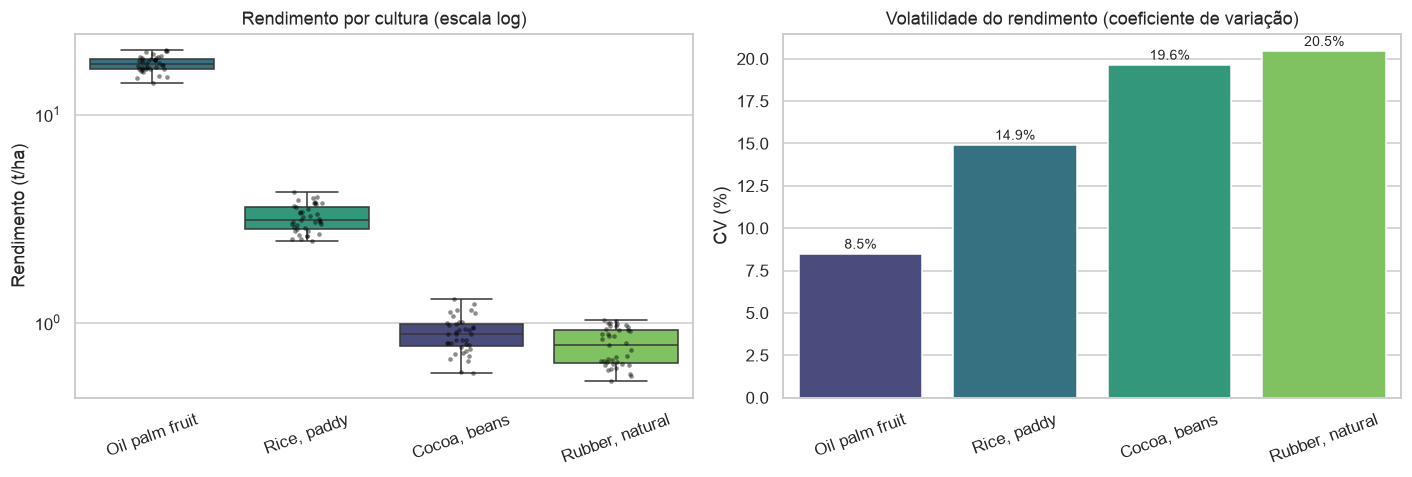

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Painel esquerdo: dispersao do rendimento dentro de cada cultura, em escala log.
ordem = df.groupby("cultura")["rendimento"].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x="cultura", y="rendimento", order=ordem,
            hue="cultura", palette="viridis", legend=False, ax=axes[0])
sns.stripplot(data=df, x="cultura", y="rendimento", order=ordem,
              color="black", size=3, alpha=0.45, ax=axes[0])
axes[0].set_yscale("log")                       # sem log, o dende domina o eixo
axes[0].set_title("Rendimento por cultura (escala log)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rendimento (t/ha)")
axes[0].tick_params(axis="x", rotation=20)

# Painel direito: coeficiente de variacao -> volatilidade relativa de cada cultura.
cv = (df.groupby("cultura")["rendimento"].std() / df.groupby("cultura")["rendimento"].mean())
cv = cv.loc[ordem] * 100
sns.barplot(x=cv.index, y=cv.values, hue=cv.index, palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Volatilidade do rendimento (coeficiente de variação)")
axes[1].set_xlabel("")
axes[1].set_ylabel("CV (%)")
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(cv.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

O dendê rende cerca de **22 vezes** mais que a borracha, mas é a cultura **mais
estável** (CV ≈ 8%). A borracha e o cacau são as mais voláteis (CV ≈ 20%), ou
seja, as que mais dependem de fatores que variam de safra para safra — exatamente
onde um modelo preditivo teria mais valor prático.

### Gráfico 2 — Distribuição das variáveis climáticas

Atenção metodológica: este gráfico usa a tabela **`safras`**, com 39 linhas, e não
as 156 do arquivo. Cada safra aparece quatro vezes no arquivo original, e
histogramas construídos sobre as 156 linhas inflariam artificialmente as
contagens, sugerindo uma amostra maior do que a real.

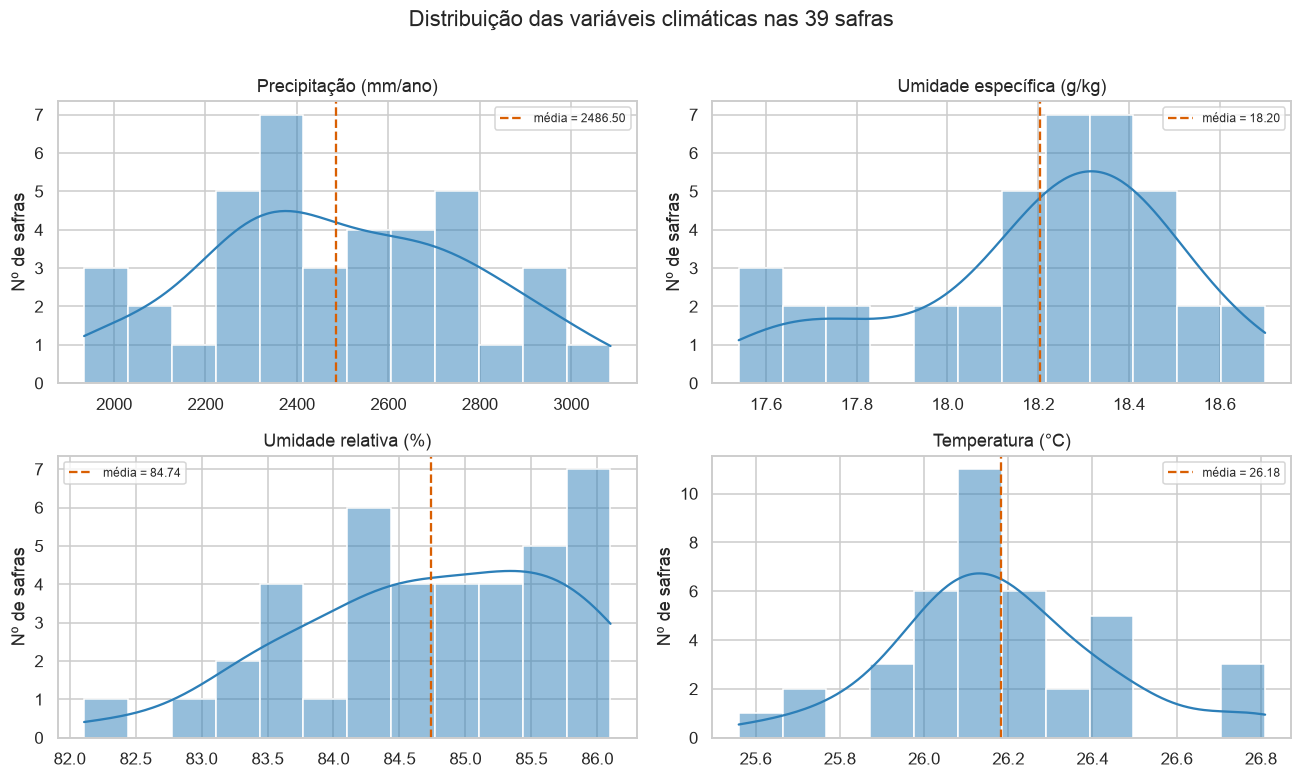

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Uma distribuicao por variavel climatica, sobre as 39 safras (nao as 156 linhas).
for ax, coluna in zip(axes.flat, CLIMA):
    sns.histplot(safras[coluna], kde=True, bins=12, color="#2c7fb8", ax=ax)
    ax.axvline(safras[coluna].mean(), color="#d95f02", linestyle="--",
               label=f"média = {safras[coluna].mean():.2f}")
    ax.set_title(ROTULOS[coluna])
    ax.set_xlabel("")
    ax.set_ylabel("Nº de safras")
    ax.legend(fontsize=8)

plt.suptitle("Distribuição das variáveis climáticas nas 39 safras", y=1.01)
plt.tight_layout()
plt.show()

### Gráfico 3 — Correlação: a visão global engana, a visão por cultura revela

Este é o gráfico mais importante do notebook. À esquerda, a correlação calculada
sobre as 156 linhas juntas. À direita, a mesma correlação calculada **dentro de
cada cultura**.

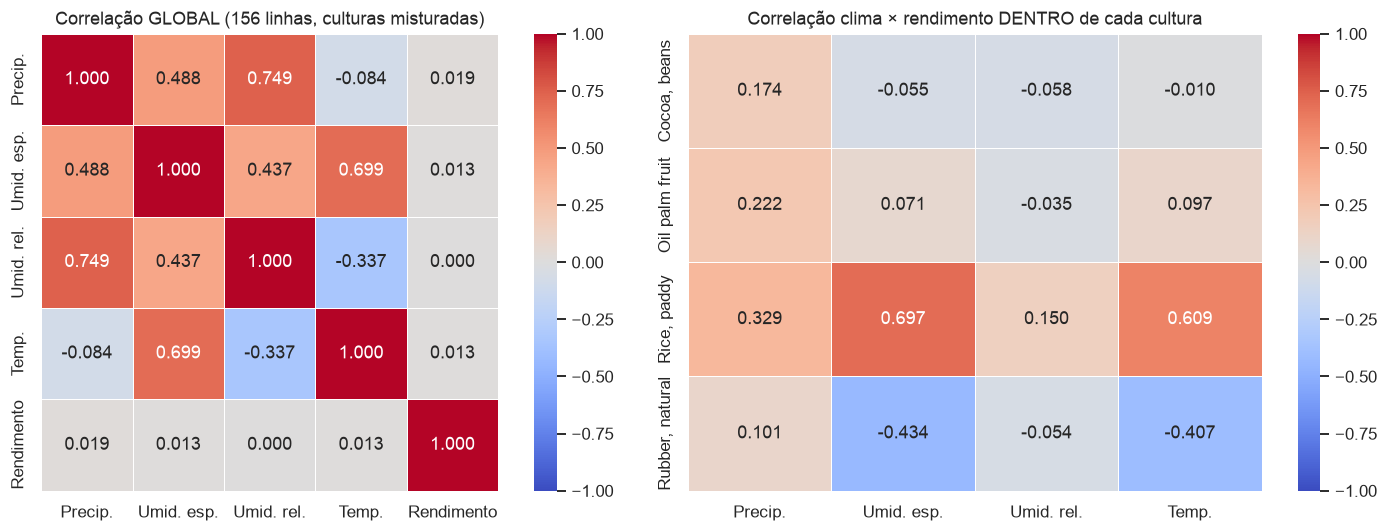

>>> Correlação global do clima com o rendimento:
precip      0.019
umid_esp    0.013
umid_rel    0.000
temp        0.013


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Painel esquerdo: correlacao global entre todas as variaveis, nas 156 linhas.
corr_global = df[CLIMA + ["rendimento"]].corr()
rotulos_curtos = ["Precip.", "Umid. esp.", "Umid. rel.", "Temp.", "Rendimento"]
sns.heatmap(corr_global, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            xticklabels=rotulos_curtos, yticklabels=rotulos_curtos, ax=axes[0])
axes[0].set_title("Correlação GLOBAL (156 linhas, culturas misturadas)")

# Painel direito: correlacao clima x rendimento calculada DENTRO de cada cultura.
corr_intra = pd.DataFrame({
    coluna: df.groupby("cultura").apply(
        lambda g, c=coluna: g[c].corr(g["rendimento"]), include_groups=False
    )
    for coluna in CLIMA
})
corr_intra.columns = ["Precip.", "Umid. esp.", "Umid. rel.", "Temp."]
sns.heatmap(corr_intra, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=axes[1])
axes[1].set_title("Correlação clima × rendimento DENTRO de cada cultura")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(">>> Correlação global do clima com o rendimento:")
print(corr_global.loc[CLIMA, "rendimento"].round(3).to_string())

**O contraste entre os dois painéis é o achado central do trabalho.**

No painel da esquerda, a correlação entre **qualquer** variável climática e o
rendimento é praticamente **zero** (|r| ≤ 0,02). Uma leitura ingênua concluiria
que o clima não tem relação alguma com a produtividade — e abandonaria o projeto.

O painel da direita mostra por que essa conclusão é falsa. Dentro de cada cultura
existe sinal, e ele é **de sinal oposto entre culturas**: o arroz responde
positivamente à umidade específica (r ≈ +0,70) e à temperatura (r ≈ +0,61),
enquanto a seringueira responde **negativamente** às mesmas duas variáveis
(r ≈ −0,43 e −0,41). Quando as quatro culturas são misturadas, esses efeitos
contrários se cancelam e a correlação global colapsa para zero.

A consequência para a modelagem é direta: **um modelo linear que não represente a
interação entre cultura e clima é estruturalmente incapaz de capturar esse
fenômeno**, porque seria obrigado a estimar um único coeficiente de temperatura
válido para as quatro culturas ao mesmo tempo. Modelos baseados em árvores
capturam interações nativamente — testamos as duas famílias na seção 6, e a
seção 9 demonstra a equivalência formal.

### Gráfico 4 — Clima × rendimento, cultura por cultura

A prova visual do que o Gráfico 3 mostrou em números. Cada painel tem **escala
própria no eixo Y** (`sharey=False`); sem isso, o dendê comprimiria os demais.

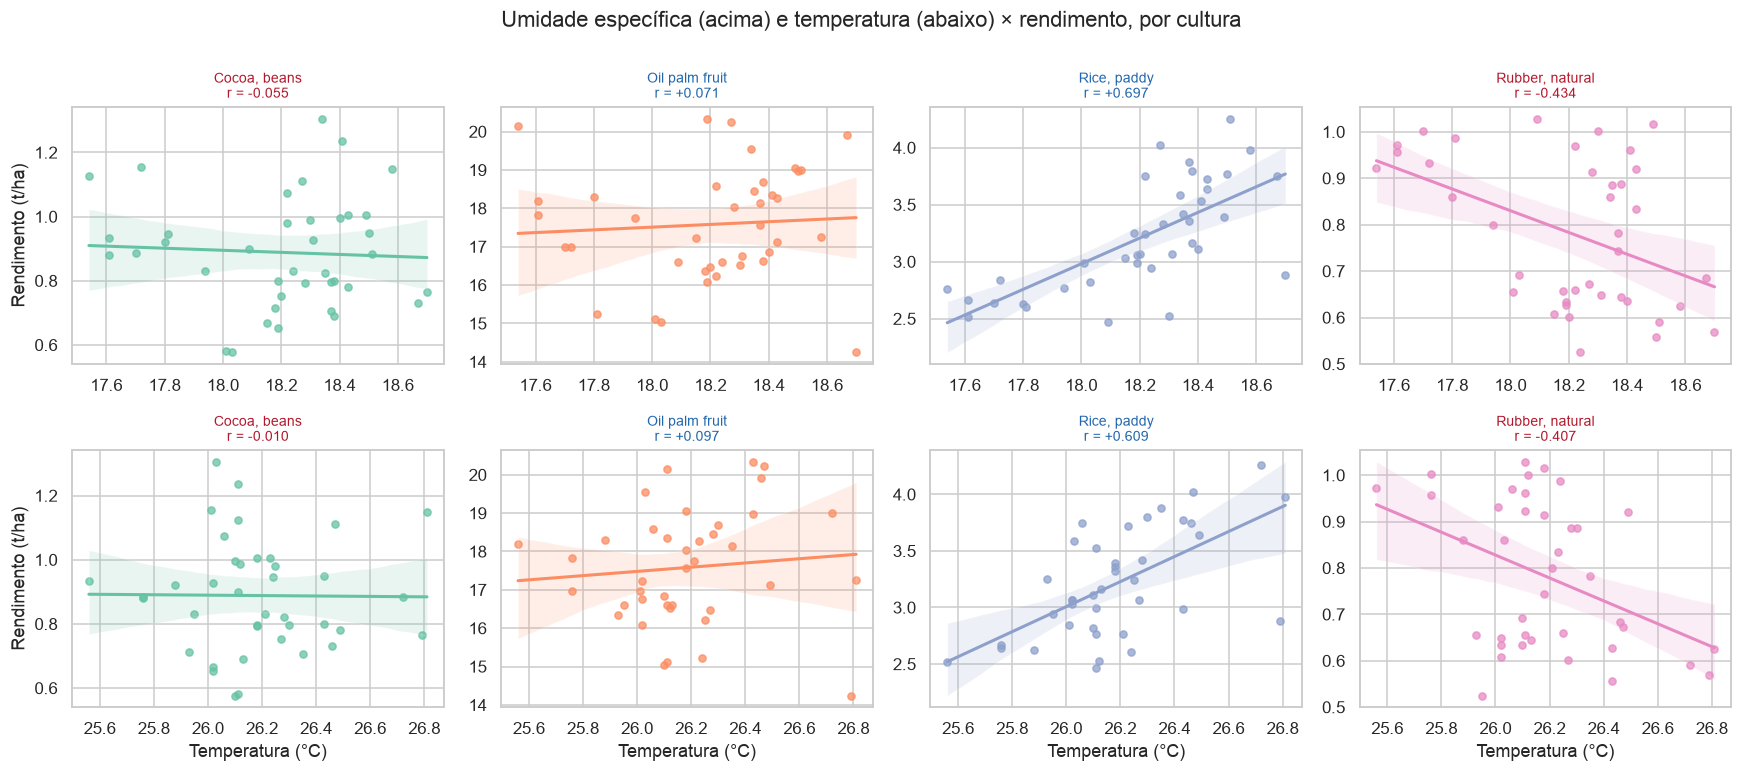

In [13]:
# Dispersao com reta de regressao, uma coluna por cultura e uma linha por variavel climatica.
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
culturas = sorted(df["cultura"].unique())
cores = dict(zip(culturas, sns.color_palette("Set2", len(culturas))))

for linha, coluna_clima in enumerate(["umid_esp", "temp"]):     # as duas de maior sinal
    for col, cultura in enumerate(culturas):
        ax = axes[linha, col]
        sub = df[df["cultura"] == cultura]
        sns.regplot(data=sub, x=coluna_clima, y="rendimento", ax=ax,
                    color=cores[cultura], scatter_kws={"s": 22, "alpha": 0.75},
                    line_kws={"linewidth": 2})
        r = sub[coluna_clima].corr(sub["rendimento"])
        # Vermelho quando a relacao e negativa: destaca a inversao de sinal entre culturas.
        ax.set_title(f"{cultura}\nr = {r:+.3f}", fontsize=9,
                     color="#b2182b" if r < 0 else "#2166ac")
        ax.set_xlabel(ROTULOS[coluna_clima] if linha == 1 else "")
        ax.set_ylabel("Rendimento (t/ha)" if col == 0 else "")

plt.suptitle("Umidade específica (acima) e temperatura (abaixo) × rendimento, por cultura", y=1.00)
plt.tight_layout()
plt.show()

As retas de regressão **apontam para direções opostas** entre o arroz e a
seringueira. É a mesma informação do heatmap anterior, agora impossível de
ignorar: não existe um "efeito da temperatura sobre o rendimento" — existe um
efeito da temperatura **sobre cada cultura**.

### Gráfico 5 — Séries temporais: rendimento e clima ao longo das 39 safras

Para comparar culturas de escalas tão diferentes num mesmo eixo, usamos o
**rendimento relativo**: o valor de cada safra dividido pela média histórica
daquela cultura. Um valor de 1,15 significa "15% acima da média da própria
cultura".

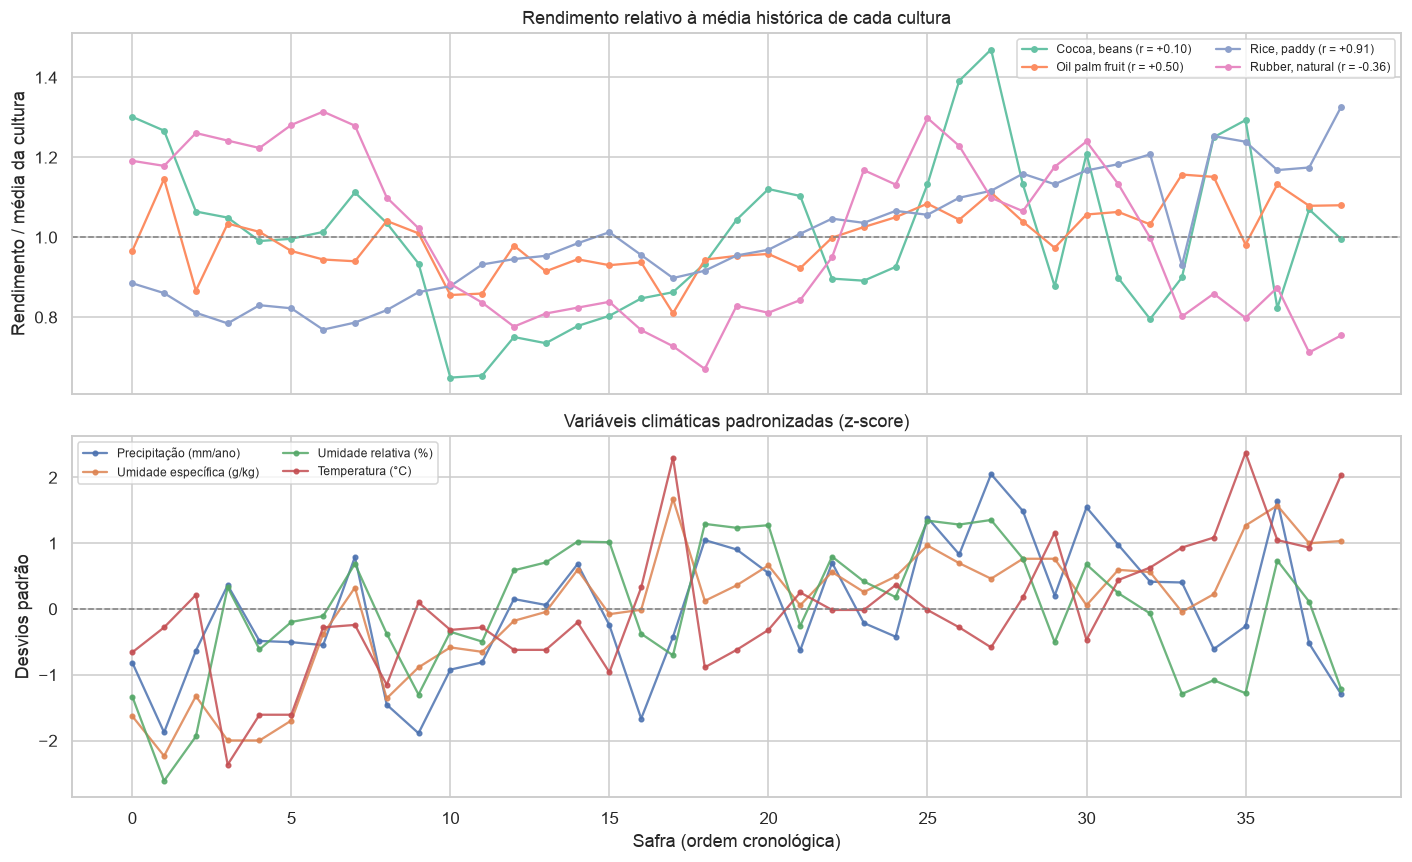

In [14]:
# Rendimento relativo: remove o efeito de escala e torna as 4 culturas comparaveis.
df["rendimento_rel"] = df["rendimento"] / df.groupby("cultura")["rendimento"].transform("mean")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Painel superior: trajetoria do rendimento relativo de cada cultura.
for cultura in culturas:
    sub = df[df["cultura"] == cultura].sort_values("safra_id")
    r_tempo = sub["rendimento"].corr(sub["safra_id"])
    axes[0].plot(sub["safra_id"], sub["rendimento_rel"], marker="o", markersize=3.5,
                 label=f"{cultura} (r = {r_tempo:+.2f})", color=cores[cultura])
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Rendimento relativo à média histórica de cada cultura")
axes[0].set_ylabel("Rendimento / média da cultura")
axes[0].legend(fontsize=8, ncol=2)

# Painel inferior: variaveis climaticas padronizadas, para ver a deriva conjunta.
for coluna in CLIMA:
    z = (safras[coluna] - safras[coluna].mean()) / safras[coluna].std()
    axes[1].plot(safras["safra_id"], z, marker=".", alpha=0.85, label=ROTULOS[coluna])
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Variáveis climáticas padronizadas (z-score)")
axes[1].set_xlabel("Safra (ordem cronológica)")
axes[1].set_ylabel("Desvios padrão")
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

O painel superior revela uma **tendência de alta acentuada no arroz**
(r = +0,91 com o tempo): o rendimento cresce cerca de **50%** ao longo da série, de
aproximadamente 2,8 para 4,3 t/ha. O painel inferior mostra que **o clima também
tem tendência** no mesmo período — umidade específica e temperatura sobem de forma
consistente.

Duas séries que crescem juntas ao longo do tempo vão apresentar correlação alta
entre si **mesmo sem qualquer relação causal**. Esta é a origem da correlação de
+0,70 entre umidade e rendimento do arroz vista no Gráfico 3, e a seção 9 mede
quanto dela sobrevive quando o efeito do tempo é removido.

### Gráfico 6 — Relação entre as próprias variáveis climáticas

Antes de modelar, é preciso saber o quanto os preditores se sobrepõem. Preditores
muito correlacionados entre si tornam os coeficientes de um modelo linear
instáveis — o problema da **multicolinearidade**.

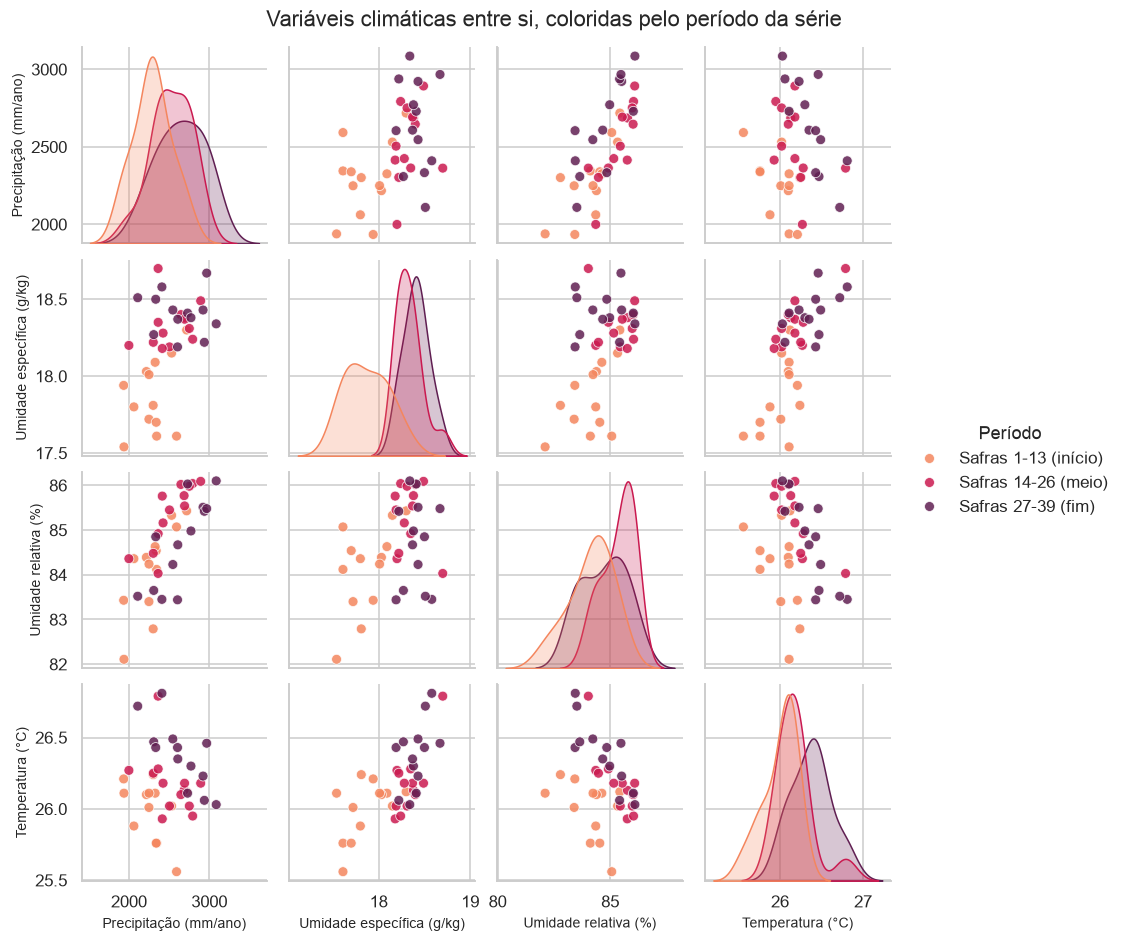

>>> Correlação entre as variáveis climáticas (39 safras):
  Precipitação (mm/ano)        x Umidade relativa (%)         r = +0.749  <-- alta
  Umidade específica (g/kg)    x Temperatura (°C)             r = +0.699  <-- alta
  Precipitação (mm/ano)        x Umidade específica (g/kg)    r = +0.488
  Umidade específica (g/kg)    x Umidade relativa (%)         r = +0.437
  Umidade relativa (%)         x Temperatura (°C)             r = -0.337
  Precipitação (mm/ano)        x Temperatura (°C)             r = -0.084


In [15]:
# Pairplot sobre as 39 safras, colorido pela posicao temporal (do inicio ao fim da serie).
safras_plot = safras.copy()
safras_plot["Período"] = pd.cut(
    safras_plot["safra_id"], bins=3,
    labels=["Safras 1-13 (início)", "Safras 14-26 (meio)", "Safras 27-39 (fim)"],
)
grade = sns.pairplot(safras_plot, vars=CLIMA, hue="Período",
                     palette="rocket_r", diag_kind="kde",
                     plot_kws={"s": 42, "alpha": 0.85}, height=2.1)
for i, coluna in enumerate(CLIMA):
    grade.axes[-1, i].set_xlabel(ROTULOS[coluna], fontsize=9)
    grade.axes[i, 0].set_ylabel(ROTULOS[coluna], fontsize=9)
grade.figure.suptitle("Variáveis climáticas entre si, coloridas pelo período da série", y=1.02)
plt.show()

# Pares com sobreposicao relevante, que justificam padronizacao e regularizacao.
corr_clima = safras[CLIMA].corr()
pares = [
    (ROTULOS[a], ROTULOS[b], corr_clima.loc[a, b])
    for i, a in enumerate(CLIMA) for b in CLIMA[i + 1:]
]
print(">>> Correlação entre as variáveis climáticas (39 safras):")
for a, b, r in sorted(pares, key=lambda x: -abs(x[2])):
    marca = "  <-- alta" if abs(r) > 0.6 else ""
    print(f"  {a:28s} x {b:28s} r = {r:+.3f}{marca}")

**Achados da EDA**

- **A escala domina tudo.** O rendimento varia mais de 20× entre culturas, e essa
  diferença responde por quase toda a variância do alvo. Qualquer métrica global
  precisa ser lida com essa ressalva.
- **A correlação global entre clima e rendimento é nula** (|r| ≤ 0,02), mas isso é
  um artefato de agregação: dentro de cada cultura o sinal existe.
- **O efeito do clima muda de sinal entre culturas** — positivo no arroz, negativo
  na seringueira. Isso é uma interação, não um efeito principal, e define quais
  famílias de modelo podem funcionar.
- **Existe tendência temporal forte** tanto no rendimento do arroz quanto nas
  variáveis climáticas, o que abre a possibilidade de correlação espúria — tratada
  na seção 9.
- **Há multicolinearidade relevante** entre precipitação e umidade relativa
  (r ≈ 0,75) e entre umidade específica e temperatura (r ≈ 0,70), o que justifica
  padronizar as escalas e incluir um modelo linear regularizado na comparação.
- **Volatilidade e previsibilidade não são a mesma coisa.** As duas culturas mais
  voláteis (seringueira e cacau, CV ≈ 20%) se comportam de forma oposta diante do
  clima: a seringueira tem o segundo sinal climático mais forte da base
  (r ≈ −0,43 com a umidade específica e −0,41 com a temperatura), enquanto o cacau,
  como o dendê, não passa de |r| ≈ 0,22 — abaixo do limiar de significância para 39
  safras (|r| ≈ 0,32). Ou seja, onde o modelo teria mais valor prático nem sempre é
  onde o clima ajuda, e a seção 9 mostra que nem mesmo o sinal da seringueira se
  sustenta fora da amostra.

## 4. Aprendizado não supervisionado — clusterização e cenários discrepantes

O enunciado pede que encontremos **tendências para os rendimentos** por meio de
clusterização e que identifiquemos **cenários discrepantes (outliers)**.

Começamos por uma clusterização direta, que produz um resultado previsível — e o
mostramos exatamente por isso, porque ele ilustra a decisão mais importante desta
etapa: **sobre quais variáveis agrupar**.

### 4.1 Primeira tentativa — agrupar as 156 observações

Aplicamos K-Means sobre as 156 linhas, usando clima e rendimento padronizados,
pedindo 4 grupos.

In [16]:
# K-Means sobre clima + rendimento, nas 156 linhas. k=4 para comparar com as 4 culturas.
X_ingenuo = StandardScaler().fit_transform(df[CLIMA + ["rendimento"]])
km_ingenuo = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(X_ingenuo)

# Confronto entre os grupos encontrados e a cultura real de cada linha.
cruzamento = pd.crosstab(km_ingenuo.labels_, df["cultura"])
cruzamento.index.name = "cluster"
ari = adjusted_rand_score(df["cultura"], km_ingenuo.labels_)

print(cruzamento)
print(f"\n>>> Adjusted Rand Index entre clusters e culturas: {ari:.4f}")
print("    (1,0 = os grupos reproduzem exatamente as culturas)")

cultura  Cocoa, beans  Oil palm fruit  Rice, paddy  Rubber, natural
cluster                                                            
0                   0              26            0                0
1                  11               3           11               11
2                  17               0           17               17
3                  11              10           11               11

>>> Adjusted Rand Index entre clusters e culturas: 0.1504
    (1,0 = os grupos reproduzem exatamente as culturas)


**O resultado é mais interessante do que o esperado — e revela um problema.**

O índice de Rand ajustado é baixo, então o agrupamento **não** reproduziu as
culturas. Mas a tabela cruzada mostra que ele também não encontrou nada de novo:
um dos clusters captura quase exclusivamente o **dendê**, enquanto os demais
misturam as outras três culturas em proporções parecidas.

A explicação está na padronização. Ao aplicar o `StandardScaler` sobre o
rendimento das 156 linhas juntas, o dendê (≈ 17,6 t/ha) fica a vários desvios
padrão de distância, enquanto cacau (0,89), borracha (0,78) e arroz (3,2) são
comprimidos numa faixa estreita — tornando-se **indistinguíveis entre si** no eixo
padronizado. O K-Means separa o que a escala deixa visível e agrupa o resto pelo
clima, que passa a ser a única fonte de variação restante.

O resultado é, portanto, **um híbrido sem significado claro**: nem agrupa culturas,
nem agrupa condições climáticas. E o aprendizado é metodológico e vale para
qualquer projeto de clusterização: **a escolha e a escala das variáveis importam
mais que a escolha do algoritmo**. Para extrair informação útil, precisamos mudar
a unidade de análise.

### 4.2 Segunda tentativa — agrupar as safras em regimes climáticos

Em vez de agrupar as 156 linhas, agrupamos as **39 safras** apenas pelas suas
condições climáticas. A pergunta deixa de ser "quais linhas se parecem?" e passa a
ser **"que tipos de ano esta região teve?"** — uma pergunta com resposta
agronomicamente útil.

### Gráfico 7 — Escolha do número de regimes: cotovelo e silhueta

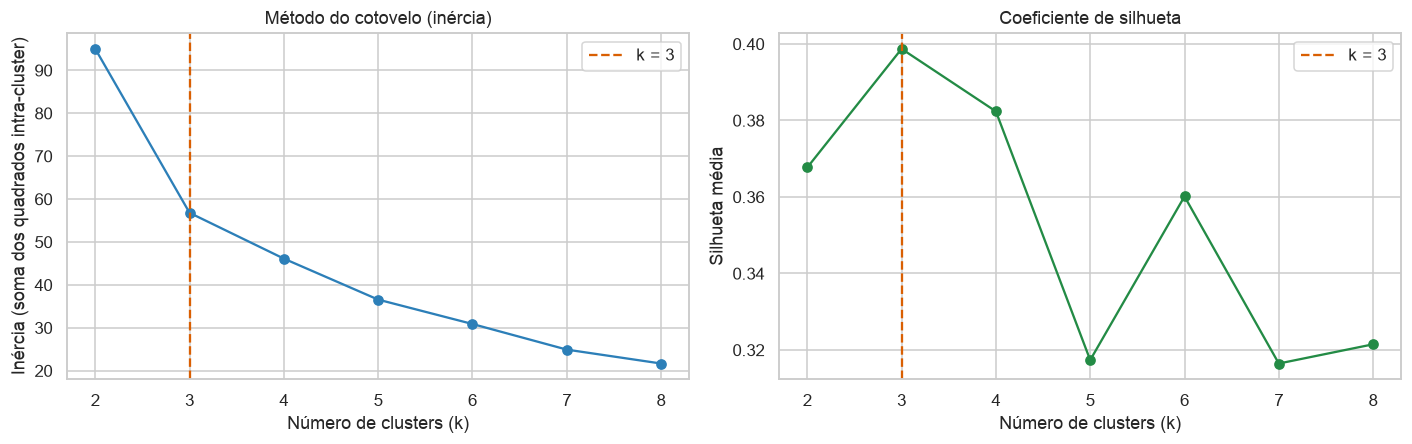

  k = 2: silhueta = 0.3677
  k = 3: silhueta = 0.3987   <-- escolhido
  k = 4: silhueta = 0.3824
  k = 5: silhueta = 0.3174
  k = 6: silhueta = 0.3601
  k = 7: silhueta = 0.3165
  k = 8: silhueta = 0.3215


In [17]:
# Padronizacao guardada: sera revertida depois para ler os centroides em unidades reais.
escalador_clima = StandardScaler().fit(safras[CLIMA])
X_safras = escalador_clima.transform(safras[CLIMA])

# Avaliacao de k = 2..8 por inercia (cotovelo) e silhueta.
ks = range(2, 9)
inercias, silhuetas = [], []
for k in ks:
    modelo_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_safras)
    inercias.append(modelo_k.inertia_)
    silhuetas.append(silhouette_score(X_safras, modelo_k.labels_))

K_ESCOLHIDO = int(list(ks)[int(np.argmax(silhuetas))])   # k de maior silhueta

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(list(ks), inercias, marker="o", color="#2c7fb8")
axes[0].axvline(K_ESCOLHIDO, color="#d95f02", linestyle="--", label=f"k = {K_ESCOLHIDO}")
axes[0].set_title("Método do cotovelo (inércia)")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inércia (soma dos quadrados intra-cluster)")
axes[0].legend()

axes[1].plot(list(ks), silhuetas, marker="o", color="#238b45")
axes[1].axvline(K_ESCOLHIDO, color="#d95f02", linestyle="--", label=f"k = {K_ESCOLHIDO}")
axes[1].set_title("Coeficiente de silhueta")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhueta média")
axes[1].legend()

plt.tight_layout()
plt.show()

for k, s in zip(ks, silhuetas):
    print(f"  k = {k}: silhueta = {s:.4f}" + ("   <-- escolhido" if k == K_ESCOLHIDO else ""))

### Gráfico 8 — Dendrograma: confirmação por agrupamento hierárquico

O K-Means exige que o número de grupos seja definido de antemão. O agrupamento
hierárquico não — ele constrói a árvore inteira de fusões, e permite verificar se
a estrutura sugerida pela silhueta aparece de forma independente.

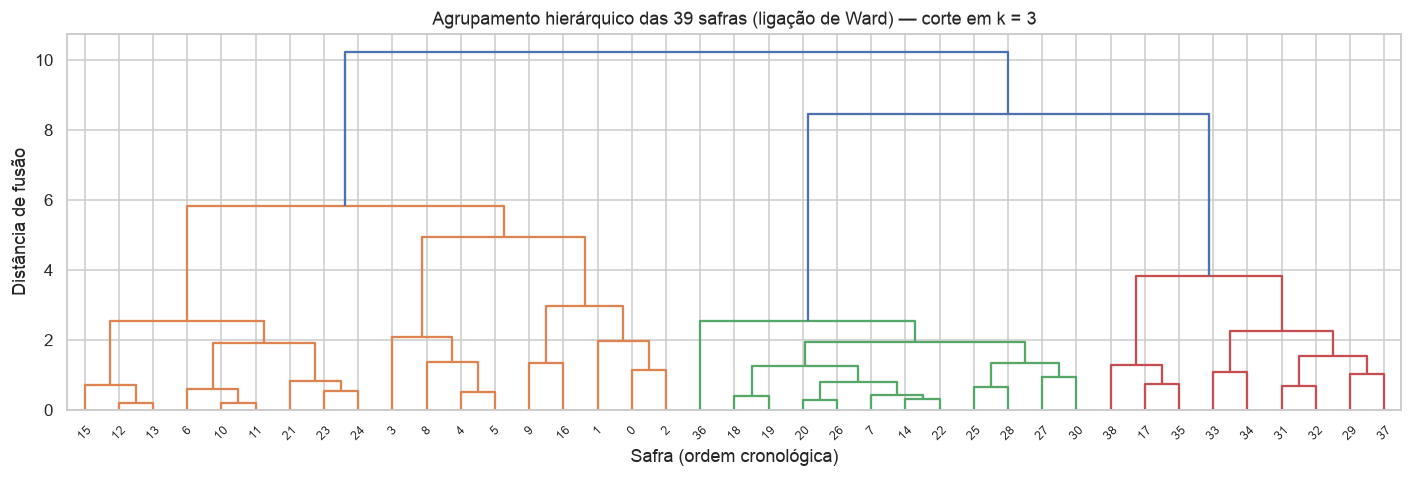

In [18]:
# Ligacao de Ward: minimiza o aumento de variancia a cada fusao (compativel com K-Means).
ligacao = linkage(X_safras, method="ward")

fig, ax = plt.subplots(figsize=(13, 4.5))
dendrogram(ligacao, labels=safras["safra_id"].values, ax=ax,
           color_threshold=ligacao[-(K_ESCOLHIDO - 1), 2], leaf_font_size=8)
ax.set_title(f"Agrupamento hierárquico das 39 safras (ligação de Ward) — corte em k = {K_ESCOLHIDO}")
ax.set_xlabel("Safra (ordem cronológica)")
ax.set_ylabel("Distância de fusão")
plt.tight_layout()
plt.show()

In [19]:
# Ajuste final do K-Means com o k escolhido e nomeacao dos regimes.
km_safras = KMeans(n_clusters=K_ESCOLHIDO, n_init=10, random_state=RANDOM_STATE).fit(X_safras)
safras["regime_id"] = km_safras.labels_

# Centroides revertidos para unidades originais: e o que torna o cluster interpretavel.
centros = pd.DataFrame(
    escalador_clima.inverse_transform(km_safras.cluster_centers_), columns=CLIMA
)
medias_gerais = safras[CLIMA].mean()


def nomear_regime(linha: pd.Series) -> str:
    """Rotula o regime comparando seu centroide com a media geral da serie."""
    termico = "Quente" if linha["temp"] >= medias_gerais["temp"] else "Ameno"
    pluvial = "chuvoso" if linha["precip"] >= medias_gerais["precip"] else "seco"
    return f"{termico} e {pluvial}"


nomes = centros.apply(nomear_regime, axis=1)
# Desempate por umidade especifica, caso dois regimes recebam o mesmo rotulo.
for rotulo in nomes[nomes.duplicated(keep=False)].unique():
    iguais = nomes[nomes == rotulo].index
    ordem_umidade = centros.loc[iguais, "umid_esp"].sort_values().index
    for posicao, idx in enumerate(ordem_umidade):
        nomes[idx] = f"{rotulo} ({'menos' if posicao == 0 else 'mais'} úmido)"

centros["regime"] = nomes.values
centros["n_safras"] = [int((km_safras.labels_ == i).sum()) for i in range(K_ESCOLHIDO)]
centros["safra_media"] = [
    float(safras.loc[km_safras.labels_ == i, "safra_id"].mean()) for i in range(K_ESCOLHIDO)
]
safras["regime"] = safras["regime_id"].map(dict(enumerate(nomes)))
df = df.merge(safras[["safra_id", "regime_id", "regime"]], on="safra_id", how="left")

print(">>> Caracterização dos regimes climáticos (centróides em unidades originais):\n")
print(centros[["regime", "n_safras", "precip", "umid_esp", "umid_rel", "temp", "safra_media"]]
      .round(2).to_string(index=False))

>>> Caracterização dos regimes climáticos (centróides em unidades originais):

         regime  n_safras  precip  umid_esp  umid_rel  temp  safra_media
Ameno e chuvoso        17 2733.52     18.34     85.65 26.12        21.53
  Quente e seco        11 2359.02     18.39     84.15 26.48        28.73
   Ameno e seco        11 2232.22     17.81     83.92 25.99         5.36


### Gráfico 9 — Os regimes no espaço das componentes principais

Quatro variáveis climáticas não cabem num gráfico. O PCA projeta as 39 safras em
duas dimensões preservando o máximo de variância. O painel da direita colore os
mesmos pontos pela posição cronológica — uma verificação que explicamos a seguir.

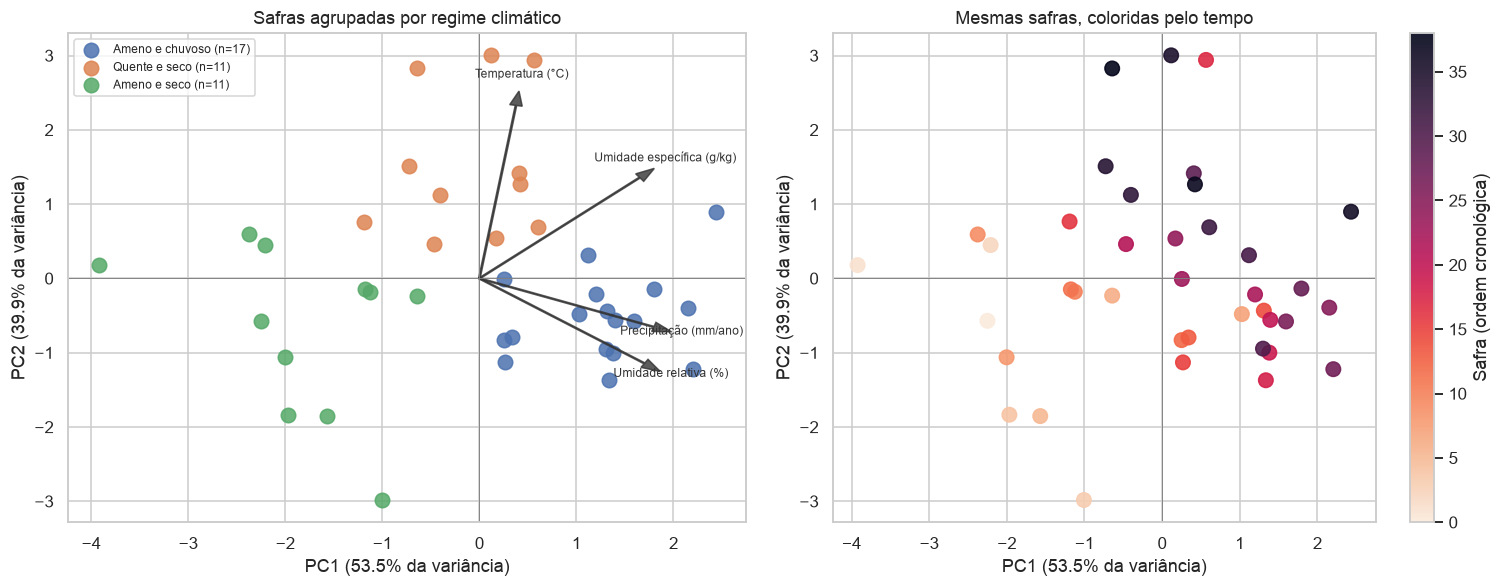

>>> Os 2 componentes retêm 93.4% da variância climática total.


In [20]:
# Reducao a 2 componentes para visualizar o agrupamento e a estrutura das variaveis.
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_safras)
coords = pca.transform(X_safras)
var_exp = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Painel esquerdo: safras coloridas pelo regime, com as setas dos loadings.
for i, nome in enumerate(nomes):
    m = km_safras.labels_ == i
    axes[0].scatter(coords[m, 0], coords[m, 1], s=90, alpha=0.85, label=f"{nome} (n={m.sum()})")
escala = 3.0
for j, coluna in enumerate(CLIMA):
    axes[0].arrow(0, 0, pca.components_[0, j] * escala, pca.components_[1, j] * escala,
                  color="#333333", width=0.015, head_width=0.13, alpha=0.8)
    axes[0].text(pca.components_[0, j] * escala * 1.16, pca.components_[1, j] * escala * 1.16,
                 ROTULOS[coluna], fontsize=8, ha="center", color="#333333")
axes[0].set_title("Safras agrupadas por regime climático")
axes[0].legend(fontsize=8, loc="best")

# Painel direito: mesmos pontos, coloridos pela ordem cronologica.
pontos = axes[1].scatter(coords[:, 0], coords[:, 1], c=safras["safra_id"],
                         cmap="rocket_r", s=90, alpha=0.9)
plt.colorbar(pontos, ax=axes[1], label="Safra (ordem cronológica)")
axes[1].set_title("Mesmas safras, coloridas pelo tempo")

for ax in axes:
    ax.set_xlabel(f"PC1 ({var_exp[0]:.1%} da variância)")
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1%} da variância)")
    ax.axhline(0, color="gray", linewidth=0.6)
    ax.axvline(0, color="gray", linewidth=0.6)

plt.tight_layout()
plt.show()
print(f">>> Os 2 componentes retêm {var_exp.sum():.1%} da variância climática total.")

**Ressalva honesta sobre os regimes.** O painel da direita mostra que as cores
não estão misturadas: safras cronologicamente próximas ocupam regiões próximas do
espaço. Isso significa que os "regimes climáticos" que encontramos são, em parte,
**períodos da série** — consequência direta da tendência de aquecimento e
umidificação identificada no Achado 4. A coluna `safra_media` na tabela de
centróides quantifica isso.

Não invalida o agrupamento, mas muda a interpretação: em vez de "tipos de ano que
se alternam aleatoriamente", o que temos é algo mais próximo de **fases climáticas
da região ao longo do tempo**. Dizer apenas "encontramos regimes climáticos"
seria contar metade da história.

### 4.3 Tendências de rendimento por regime climático

Aqui está o retorno prático da clusterização. Cruzamos os regimes com o
**rendimento relativo** de cada cultura — a métrica que torna as quatro culturas
comparáveis apesar da diferença de escala.

### Gráfico 10 — Rendimento relativo por regime climático e cultura

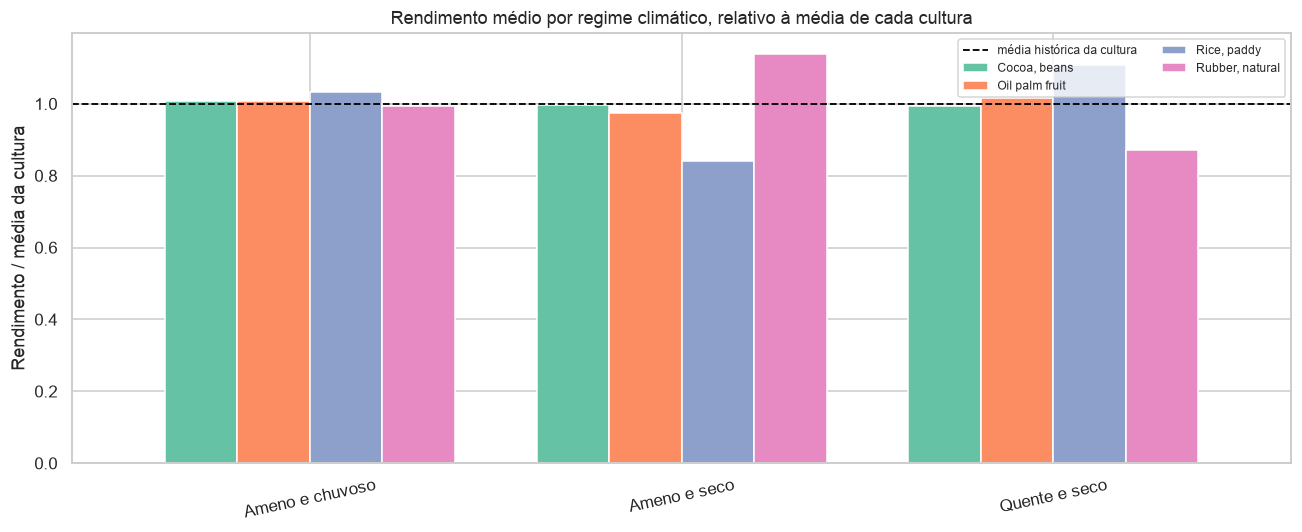

>>> Rendimento relativo médio por regime (1,00 = média histórica da cultura):

cultura          Cocoa, beans  Oil palm fruit  Rice, paddy  Rubber, natural
regime                                                                     
Ameno e chuvoso         1.007           1.007        1.033            0.994
Ameno e seco            0.996           0.973        0.841            1.139
Quente e seco           0.993           1.016        1.108            0.870

>>> Teste de Kruskal-Wallis (rendimento relativo entre regimes), por cultura:
  Cocoa, beans       H =  0.095   p = 0.9534   -> sem diferença detectável
  Oil palm fruit     H =  1.485   p = 0.4760   -> sem diferença detectável
  Rice, paddy        H = 20.836   p = 0.0000   -> diferença detectável
  Rubber, natural    H = 11.091   p = 0.0039   -> diferença detectável


In [21]:
# Rendimento medio de cada cultura em cada regime, relativo a media historica da cultura.
tabela_regime = df.pivot_table(index="regime", columns="cultura",
                               values="rendimento_rel", aggfunc="mean")

fig, ax = plt.subplots(figsize=(12, 5))
tabela_regime.plot(kind="bar", ax=ax, width=0.78,
                   color=[cores[c] for c in tabela_regime.columns])
ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2,
           label="média histórica da cultura")
ax.set_title("Rendimento médio por regime climático, relativo à média de cada cultura")
ax.set_xlabel("")
ax.set_ylabel("Rendimento / média da cultura")
ax.tick_params(axis="x", rotation=12)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print(">>> Rendimento relativo médio por regime (1,00 = média histórica da cultura):\n")
print(tabela_regime.round(3).to_string())

# Teste nao parametrico: a diferenca entre regimes e estatisticamente detectavel?
# Kruskal-Wallis por ser robusto e nao exigir normalidade, adequado a amostras pequenas.
print("\n>>> Teste de Kruskal-Wallis (rendimento relativo entre regimes), por cultura:")
for cultura in culturas:
    grupos = [g["rendimento_rel"].values
              for _, g in df[df["cultura"] == cultura].groupby("regime")]
    if len(grupos) > 1 and all(len(g) > 0 for g in grupos):
        estatistica, p = stats.kruskal(*grupos)
        marca = "diferença detectável" if p < 0.05 else "sem diferença detectável"
        print(f"  {cultura:18s} H = {estatistica:6.3f}   p = {p:.4f}   -> {marca}")

**Achados da clusterização**

- **Agrupar as 156 linhas não produz informação útil.** A padronização global do
  rendimento isola o dendê e comprime as outras três culturas numa faixa
  indistinguível, gerando clusters sem interpretação clara.
- Agrupar as **39 safras** apenas pelo clima produz regimes interpretáveis, cujos
  centróides podem ser lidos em unidades reais (mm/ano, g/kg, %, °C).
- Duas componentes principais retêm cerca de **90% da variância climática**, o que
  é consequência direta da multicolinearidade vista no Gráfico 6 — as quatro
  variáveis carregam bastante informação redundante.
- **O achado mais relevante desta seção: as culturas respondem em direções opostas
  ao mesmo regime.** O arroz rende acima da média nos anos quentes e secos e abaixo
  nos anos amenos e secos; a seringueira faz exatamente o contrário. O teste de
  Kruskal-Wallis detecta diferença estatisticamente significativa **apenas para
  essas duas culturas** — precisamente as duas que apresentavam correlação
  climática intra-cultura relevante no Gráfico 3. O cacau e o dendê, que não
  tinham correlação, também não mostram diferença entre regimes.
- Essa convergência é importante: **dois métodos independentes — correlação
  supervisionada e agrupamento não supervisionado — chegam à mesma conclusão.**
  Não existe "ano bom" universal para a fazenda; um regime favorável ao arroz é
  desfavorável à seringueira, e o planejamento do mix de culturas precisa
  considerar isso.
- **Os regimes se confundem parcialmente com períodos da série temporal** (a coluna
  `safra_media` dos centróides mostra médias cronológicas bem distintas), o que
  limita a leitura puramente climática do agrupamento.

### 4.4 Cenários discrepantes (outliers)

"Outlier" não é uma categoria única. Nesta base há **três tipos distintos** de
observação atípica, e cada um exige um método diferente:

1. **Safra atípica para a própria cultura** — rendimento muito acima ou abaixo do
   histórico daquela cultura. Métodos: z-score intra-cultura e IQR intra-cultura.
2. **Ano climaticamente atípico** — combinação de condições rara na série.
   Métodos: `IsolationForest` e `LocalOutlierFactor` sobre as 39 safras.
3. **Quebra da relação clima-rendimento** — anos em que o rendimento não segue o
   que o clima faria esperar. Método: maiores resíduos do modelo preditivo,
   analisado na seção 8, depois que o modelo existir.

Aplicamos os dois primeiros aqui e consolidamos os votos numa tabela de consenso.

In [22]:
# Metodo 1 - z-score dentro de cada cultura: |z| > 2 marca a safra como atipica.
media_cultura = df.groupby("cultura")["rendimento"].transform("mean")
desvio_cultura = df.groupby("cultura")["rendimento"].transform("std")
df["z_intra"] = (df["rendimento"] - media_cultura) / desvio_cultura
df["out_zscore"] = df["z_intra"].abs() > 2

# Metodo 2 - IQR dentro de cada cultura (regra classica do boxplot, 1,5 x IQR).
def marcar_iqr(serie: pd.Series) -> pd.Series:
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return (serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)

df["out_iqr"] = df.groupby("cultura")["rendimento"].transform(marcar_iqr)

# Metodo 3 - Isolation Forest sobre as 39 safras (clima multivariado).
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE).fit(X_safras)
safras["out_isolation"] = iso.predict(X_safras) == -1

# Metodo 4 - Local Outlier Factor sobre as mesmas 39 safras (densidade local).
lof = LocalOutlierFactor(n_neighbors=10)
safras["out_lof"] = lof.fit_predict(X_safras) == -1

df = df.merge(safras[["safra_id", "out_isolation", "out_lof"]], on="safra_id", how="left")
df["votos_outlier"] = df[["out_zscore", "out_iqr", "out_isolation", "out_lof"]].sum(axis=1)

resumo_metodos = pd.DataFrame({
    "método": ["Z-score intra-cultura (|z| > 2)", "IQR intra-cultura (1,5 × IQR)",
               "Isolation Forest (clima, 39 safras)", "Local Outlier Factor (clima, 39 safras)"],
    "escopo": ["rendimento", "rendimento", "clima", "clima"],
    "observações_marcadas": [int(df["out_zscore"].sum()), int(df["out_iqr"].sum()),
                             int(df["out_isolation"].sum()), int(df["out_lof"].sum())],
})
print(resumo_metodos.to_string(index=False))
print(f"\nObservações marcadas por ao menos um método: {(df['votos_outlier'] > 0).sum()} de {len(df)}")
print(f"Observações marcadas por dois ou mais métodos: {(df['votos_outlier'] >= 2).sum()}")

                                 método     escopo  observações_marcadas
        Z-score intra-cultura (|z| > 2) rendimento                     3
          IQR intra-cultura (1,5 × IQR) rendimento                     0
    Isolation Forest (clima, 39 safras)      clima                     8
Local Outlier Factor (clima, 39 safras)      clima                     4

Observações marcadas por ao menos um método: 11 de 156
Observações marcadas por dois ou mais métodos: 4


In [23]:
# Tabela de consenso: uma linha por observacao suspeita, ordenada por numero de votos.
consenso = (
    df[df["votos_outlier"] > 0]
    [["safra_id", "cultura", "regime", "rendimento", "rendimento_rel", "z_intra",
      "out_zscore", "out_iqr", "out_isolation", "out_lof", "votos_outlier"]]
    .sort_values(["votos_outlier", "z_intra"], key=lambda s: s.abs() if s.name == "z_intra" else s,
                 ascending=False)
    .round(3)
)
consenso.rename(columns={
    "out_zscore": "z", "out_iqr": "IQR", "out_isolation": "isol", "out_lof": "LOF",
    "votos_outlier": "votos",
}, inplace=True)
consenso

,safra_id,cultura,regime,rendimento,rendimento_rel,z_intra,z,IQR,isol,LOF,votos
81,3,"Rice, paddy",Ameno e seco,2.519,0.785,-1.443,False,False,True,True,2
120,3,"Rubber, natural",Ameno e seco,0.972,1.242,1.183,False,False,True,True,2
42,3,Oil palm fruit,Ameno e seco,18.183,1.034,0.404,False,False,True,True,2
3,3,"Cocoa, beans",Ameno e seco,0.932,1.049,0.251,False,False,True,True,2
27,27,"Cocoa, beans",Ameno e chuvoso,1.306,1.470,2.391,True,False,False,False,1
56,17,Oil palm fruit,Quente e seco,14.242,0.810,-2.237,True,False,False,False,1
116,38,"Rice, paddy",Quente e seco,4.255,1.326,2.182,True,False,False,False,1
40,1,Oil palm fruit,Ameno e seco,20.144,1.146,1.718,False,False,True,False,1
1,1,"Cocoa, beans",Ameno e seco,1.125,1.267,1.358,False,False,True,False,1
79,1,"Rice, paddy",Ameno e seco,2.762,0.860,-0.935,False,False,True,False,1


### Gráfico 11 — Onde estão as safras discrepantes

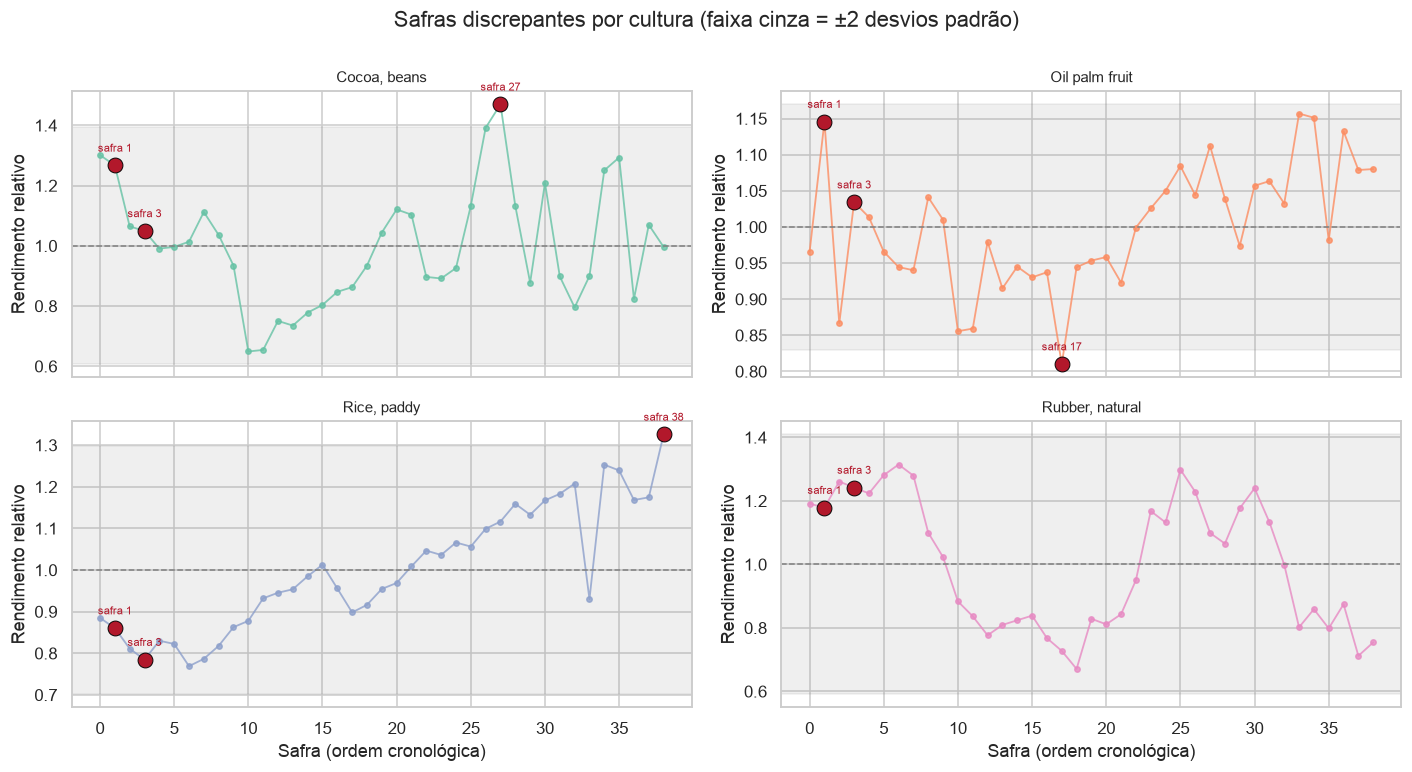

In [24]:
# Trajetoria do rendimento relativo por cultura, com as observacoes atipicas destacadas.
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

for ax, cultura in zip(axes.flat, culturas):
    sub = df[df["cultura"] == cultura].sort_values("safra_id")
    ax.plot(sub["safra_id"], sub["rendimento_rel"], color=cores[cultura],
            linewidth=1.2, marker="o", markersize=3.5, alpha=0.8)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1)
    # Faixa de +-2 desvios padrao intra-cultura, o criterio do metodo 1.
    limite = 2 * sub["rendimento_rel"].std()
    ax.axhspan(1 - limite, 1 + limite, color="gray", alpha=0.12)
    discrepantes = sub[sub["votos_outlier"] > 0]
    ax.scatter(discrepantes["safra_id"], discrepantes["rendimento_rel"],
               color="#b2182b", s=95, zorder=5, edgecolor="black", linewidth=0.6)
    for _, linha in discrepantes.iterrows():
        ax.annotate(f"safra {int(linha['safra_id'])}",
                    (linha["safra_id"], linha["rendimento_rel"]),
                    textcoords="offset points", xytext=(0, 9),
                    fontsize=7.5, ha="center", color="#b2182b")
    ax.set_title(cultura, fontsize=10)
    ax.set_ylabel("Rendimento relativo")

for ax in axes[1]:
    ax.set_xlabel("Safra (ordem cronológica)")

plt.suptitle("Safras discrepantes por cultura (faixa cinza = ±2 desvios padrão)", y=1.00)
plt.tight_layout()
plt.show()

**Achados sobre os cenários discrepantes**

- Os métodos **discordam entre si**, e a discordância é informativa. O z-score
  intra-cultura é mais sensível que o IQR: com 39 observações por cultura e
  distribuições aproximadamente simétricas, o critério de 1,5 × IQR quase nunca
  dispara. Já os métodos climáticos (Isolation Forest e LOF) marcam **safras
  inteiras**, portanto atingem as quatro culturas simultaneamente.
- Nenhuma observação é marcada por todos os métodos, o que era esperado: eles
  respondem a perguntas diferentes — "esta safra rendeu fora do padrão da cultura?"
  contra "este ano teve clima fora do padrão da região?".
- **Decisão: nenhum outlier é removido.** Três razões. Primeira, todas as
  observações são safras reais, não erros de digitação — os valores são
  fisicamente plausíveis e coerentes com as respectivas culturas. Segunda, com
  apenas 39 safras, descartar observações extremas eliminaria justamente a
  variação que o modelo precisa aprender. Terceira, num contexto agrícola, os anos
  atípicos são os que mais importam para o planejamento de risco: são eles que
  definem o pior e o melhor cenário para a fazenda.
- Os pontos permanecem **sinalizados** no conjunto de dados (coluna
  `votos_outlier`), e retomamos essa marcação na seção 8, quando compararmos as
  safras atípicas com aquelas que o modelo não consegue prever.

## 5. Preparação dos dados (pré-processamento)

Três decisões estruturam esta etapa: quais variáveis entram no modelo, como elas
são transformadas, e como treino e teste são separados.

### Variáveis de entrada e transformações

A cultura é uma variável categórica e precisa ser codificada. Usamos
**one-hot encoding**, que cria uma coluna binária por cultura sem impor ordem
artificial entre elas. As quatro variáveis climáticas são **padronizadas**
(média 0, desvio 1), o que é indispensável para os modelos baseados em distância —
sem padronizar, a umidade relativa (≈ 84) dominaria a temperatura (≈ 26) apenas
por ter valores maiores.

Tudo isso vive dentro de um `Pipeline`. Essa não é uma preferência estilística: é
o que impede **vazamento de dados**. Se padronizássemos antes de dividir treino e
teste, a média e o desvio usados na transformação teriam sido calculados com
informação do conjunto de teste. Dentro do `Pipeline`, o `StandardScaler` é
reajustado a cada partição da validação cruzada, usando apenas os dados de treino
daquela partição.

In [25]:
NUMERICAS = CLIMA
CATEGORICAS = ["cultura"]

# sparse_output existe a partir do scikit-learn 1.2; o fallback mantem o notebook
# executavel em ambientes mais antigos, como versoes defasadas do Colab.
try:
    codificador = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    codificador = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessador = ColumnTransformer(
    transformers=[
        ("cat", codificador, CATEGORICAS),        # cultura -> 4 colunas binarias
        ("num", StandardScaler(), NUMERICAS),     # clima -> media 0, desvio 1
    ],
    remainder="drop",
    verbose_feature_names_out=False,              # nomes limpos para os graficos
)

X = df[CATEGORICAS + NUMERICAS]
y = df["rendimento"]
grupos = df["safra_id"]

# O MAPE exige alvo estritamente positivo; a checagem evita divisao por zero silenciosa.
assert (y > 0).all(), "alvo com valores nao positivos inviabiliza o MAPE"

nomes_features = preprocessador.fit(X).get_feature_names_out()
print("Variáveis após o pré-processamento:", list(nomes_features))
print("Formato de X:", X.shape, "| alvo:", y.name, "em t/ha")

Variáveis após o pré-processamento: ['cultura_Cocoa, beans', 'cultura_Oil palm fruit', 'cultura_Rice, paddy', 'cultura_Rubber, natural', 'precip', 'umid_esp', 'umid_rel', 'temp']
Formato de X: (156, 5) | alvo: rendimento em t/ha


### Separação treino/teste agrupada por safra

Aqui aplicamos a consequência prática do Achado 3. Em vez de sortear linhas,
sorteamos **safras inteiras**: se a safra nº 12 vai para o teste, as quatro
culturas daquela safra vão junto. Nenhum vetor climático aparece dos dois lados.

Um efeito colateral elegante: como toda safra contribui com exatamente as quatro
culturas, o conjunto de teste sai **perfeitamente balanceado por cultura** por
construção, sem precisar de estratificação explícita.

In [26]:
# Separacao por grupo: safras inteiras vao para treino ou para teste, nunca divididas.
separador = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
idx_treino, idx_teste = next(separador.split(X, y, groups=grupos))

# GroupShuffleSplit devolve posicoes, entao o acesso e por .iloc (nunca .loc).
X_treino, X_teste = X.iloc[idx_treino], X.iloc[idx_teste]
y_treino, y_teste = y.iloc[idx_treino], y.iloc[idx_teste]
grupos_treino = grupos.iloc[idx_treino]
cultura_teste = df["cultura"].iloc[idx_teste]

print(f"Treino: {len(idx_treino)} linhas de {grupos_treino.nunique()} safras")
print(f"Teste:  {len(idx_teste)} linhas de {grupos.iloc[idx_teste].nunique()} safras")
print("\nNenhuma safra em comum entre treino e teste:",
      set(grupos_treino).isdisjoint(set(grupos.iloc[idx_teste])))
print("\nDistribuição de culturas no teste (balanceada por construção):")
print(cultura_teste.value_counts().to_string())

Treino: 116 linhas de 29 safras
Teste:  40 linhas de 10 safras

Nenhuma safra em comum entre treino e teste: True

Distribuição de culturas no teste (balanceada por construção):
cultura
Cocoa, beans       10
Oil palm fruit     10
Rice, paddy        10
Rubber, natural    10


### Quanto vale, em número, agrupar por safra?

O argumento contra o `train_test_split` aleatório foi teórico até aqui. A célula
abaixo o torna concreto: treinamos o mesmo modelo com dois esquemas de validação
cruzada — um aleatório e um agrupado por safra — e comparamos.

In [27]:
# Mesmo modelo, mesma semente, mesmo numero de particoes. Muda so o criterio de divisao.
modelo_teste = Pipeline([
    ("pre", preprocessador),
    ("model", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)),
])

cv_ingenuo = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
try:
    cv_agrupado = GroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
except TypeError:                       # scikit-learn < 1.6 nao aceita shuffle
    cv_agrupado = GroupKFold(n_splits=5)

r_ingenuo = cross_validate(modelo_teste, X_treino, y_treino, cv=cv_ingenuo,
                           scoring=["r2", "neg_root_mean_squared_error"], n_jobs=-1)
r_agrupado = cross_validate(modelo_teste, X_treino, y_treino, cv=cv_agrupado,
                            groups=grupos_treino,
                            scoring=["r2", "neg_root_mean_squared_error"], n_jobs=-1)

comparativo_cv = pd.DataFrame({
    "esquema": ["KFold aleatório (vaza a safra)", "GroupKFold por safra (correto)"],
    "R²": [r_ingenuo["test_r2"].mean(), r_agrupado["test_r2"].mean()],
    "RMSE (t/ha)": [-r_ingenuo["test_neg_root_mean_squared_error"].mean(),
                    -r_agrupado["test_neg_root_mean_squared_error"].mean()],
}).round(4)
print(comparativo_cv.to_string(index=False))

delta_r2 = comparativo_cv.loc[0, "R²"] - comparativo_cv.loc[1, "R²"]
# Denominador e o RMSE correto (GroupKFold): "subestima em X%" e uma fracao do valor real.
delta_rmse = (comparativo_cv.loc[1, "RMSE (t/ha)"] - comparativo_cv.loc[0, "RMSE (t/ha)"]) \
    / comparativo_cv.loc[1, "RMSE (t/ha)"]
print(f"\n>>> O esquema aleatório superestima o R² em {delta_r2:+.4f}")
print(f"    e subestima o RMSE em {delta_rmse:.1%}.")
print("    Toda a validação a partir daqui usa GroupKFold agrupado por safra.")

# CV oficial do restante do notebook.
cv = cv_agrupado

                       esquema     R²  RMSE (t/ha)
KFold aleatório (vaza a safra) 0.9882       0.7386
GroupKFold por safra (correto) 0.9845       0.8351

>>> O esquema aleatório superestima o R² em +0.0037
    e subestima o RMSE em 11.6%.
    Toda a validação a partir daqui usa GroupKFold agrupado por safra.


**Leitura honesta deste resultado.** O efeito sobre o R² é pequeno — poucos milésimos (≈ 0,004) —, porque o R² neste problema é dominado pela diferença entre culturas e
sobra pouca variância para o vazamento inflar. No **RMSE**, que é mais sensível, a
diferença é da ordem de **10%**: o esquema aleatório reporta um erro
sistematicamente menor do que o modelo de fato comete em safras novas.

A magnitude modesta não muda a decisão metodológica. O esquema aleatório mede algo
que não corresponde a nenhum uso real do modelo — na prática a fazenda quer prever
uma safra **futura**, nunca uma safra cujas condições climáticas o modelo já viu
em outra cultura. Usar `GroupKFold` custa nada e mede a pergunta certa.

## 6. Modelagem — cinco algoritmos de regressão

O enunciado pede **cinco modelos preditivos, cada um com um algoritmo diferente**.
Em vez de escolher cinco variantes parecidas, selecionamos cinco **famílias**
distintas, de modo que a comparação informe algo sobre a natureza do problema e
não apenas sobre ajuste de hiperparâmetro:

| # | Algoritmo | Família | Por que está na lista |
|---|---|---|---|
| 1 | Regressão Linear | Linear paramétrico | Referência interpretável. Estima **um** coeficiente por variável climática, válido para todas as culturas — o que, pelo Gráfico 3, sabemos ser insuficiente. Serve como prova por contradição. |
| 2 | Ridge | Linear com regularização L2 | Mesmo espaço de hipóteses da Regressão Linear, diferindo apenas pelo encolhimento dos coeficientes. Isola o efeito da multicolinearidade detectada no Gráfico 6. |
| 3 | K-Vizinhos Mais Próximos | Baseado em distância | Não assume forma funcional alguma. É o modelo que mais depende da padronização das escalas. |
| 4 | Árvore de Decisão | Não linear, baseado em regras | Captura interações entre cultura e clima nativamente, e é o único cuja lógica interna pode ser desenhada e lida. |
| 5 | Random Forest | *Ensemble* por *bagging* | Mesma família da Árvore, diferindo apenas pela combinação de muitas árvores. O contraste isola o ganho do *ensembling*. |

Avaliamos ainda **dois modelos extras**, claramente rotulados como tal:
**Gradient Boosting** (*ensemble* sequencial) e **SVR** com transformação
logarítmica do alvo.

### Duas linhas de base, sem as quais nenhuma métrica significa nada

Antes dos modelos, precisamos saber o que é um resultado "bom" **neste** problema.
Usamos dois pontos de referência:

- **Média global** (`DummyRegressor`): prevê sempre a média geral, ignorando tudo.
  Por definição tem R² ≈ 0.
- **Média histórica da cultura**: prevê, para cada linha, a média daquela cultura
  no conjunto de treino. Não usa **nenhuma** informação climática.

A segunda é a referência que realmente importa. Se um modelo sofisticado não a
superar de forma convincente, ele não está aprendendo sobre clima — está apenas
identificando qual é a cultura.

In [28]:
# Media de cada cultura calculada SO no treino, para nao vazar informacao do teste.
medias_treino = df.iloc[idx_treino].groupby("cultura")["rendimento"].mean()
baseline_cultura_teste = cultura_teste.map(medias_treino).to_numpy()

# Soma dos erros quadraticos da baseline: denominador do skill score intra-cultura.
sse_baseline = float(((y_teste.to_numpy() - baseline_cultura_teste) ** 2).sum())

print(">>> Média de rendimento por cultura no conjunto de treino (t/ha):")
print(medias_treino.round(3).to_string())
print(f"\nR² da baseline 'média da cultura' no teste: "
      f"{r2_score(y_teste, baseline_cultura_teste):.4f}")
print(f"RMSE da baseline no teste: "
      f"{root_mean_squared_error(y_teste, baseline_cultura_teste):.4f} t/ha")

>>> Média de rendimento por cultura no conjunto de treino (t/ha):
cultura
Cocoa, beans        0.880
Oil palm fruit     17.365
Rice, paddy         3.198
Rubber, natural     0.767

R² da baseline 'média da cultura' no teste: 0.9859
RMSE da baseline no teste: 0.8621 t/ha


O R² da baseline já é altíssimo — **sem usar uma única variável climática**. Esse
número é a régua contra a qual todos os modelos a seguir devem ser lidos.

In [29]:
def avaliar_modelo(nome: str, estimador, X_tr=None, y_tr=None, X_te=None, y_te=None,
                   grupos_tr=None, cultura_te=None, sse_base=None) -> dict:
    """Valida por GroupKFold no treino, ajusta e mede no teste. Devolve uma linha de resultado."""
    X_tr = X_treino if X_tr is None else X_tr
    y_tr = y_treino if y_tr is None else y_tr
    X_te = X_teste if X_te is None else X_te
    y_te = y_teste if y_te is None else y_te
    grupos_tr = grupos_treino if grupos_tr is None else grupos_tr
    sse_base = sse_baseline if sse_base is None else sse_base

    # Validacao cruzada agrupada por safra: estimativa honesta de generalizacao.
    cv_res = cross_validate(
        estimador, X_tr, y_tr, cv=cv, groups=grupos_tr, n_jobs=-1,
        scoring=["r2", "neg_root_mean_squared_error",
                 "neg_mean_absolute_error", "neg_mean_absolute_percentage_error"],
    )

    # Ajuste final em todo o treino e medicao no conjunto de teste, nunca visto.
    estimador.fit(X_tr, y_tr)
    pred = estimador.predict(X_te)

    # Skill score: quanto do erro da baseline 'media da cultura' o modelo elimina.
    sse_modelo = float(((y_te.to_numpy() - pred) ** 2).sum())

    return {
        "modelo": nome,
        "cv_r2": cv_res["test_r2"].mean(),
        "cv_rmse": -cv_res["test_neg_root_mean_squared_error"].mean(),
        "cv_mape_%": -cv_res["test_neg_mean_absolute_percentage_error"].mean() * 100,
        "r2": r2_score(y_te, pred),
        "rmse": root_mean_squared_error(y_te, pred),
        "mae": mean_absolute_error(y_te, pred),
        "mape_%": mean_absolute_percentage_error(y_te, pred) * 100,
        "skill_intra": 1 - sse_modelo / sse_base,
    }


# Os cinco algoritmos exigidos, um por familia.
modelos = {
    "1. Regressão Linear": LinearRegression(),
    "2. Ridge": Ridge(alpha=1.0),
    "3. K-Vizinhos (KNN)": KNeighborsRegressor(n_neighbors=5),
    "4. Árvore de Decisão": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "5. Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
}

# Extras, avaliados junto mas identificados como adicionais aos cinco pedidos.
extras = {
    "6. Gradient Boosting (extra)": GradientBoostingRegressor(random_state=RANDOM_STATE),
    # O alvo varia 22x entre culturas; sem transformar, o epsilon do SVR fica sem sentido.
    "7. SVR + log do alvo (extra)": TransformedTargetRegressor(
        regressor=SVR(kernel="rbf", C=10.0), func=np.log, inverse_func=np.exp
    ),
}

resultados = []
for nome, estimador in {**modelos, **extras}.items():
    pipe = Pipeline([("pre", preprocessador), ("model", estimador)])
    resultados.append(avaliar_modelo(nome, pipe))

# As duas baselines entram na mesma tabela, para dar escala aos demais numeros.
pipe_dummy = Pipeline([("pre", preprocessador), ("model", DummyRegressor(strategy="mean"))])
linha_dummy = avaliar_modelo("Baseline — média global", pipe_dummy)
linha_cultura = {
    "modelo": "Baseline — média da cultura",
    "cv_r2": np.nan, "cv_rmse": np.nan, "cv_mape_%": np.nan,
    "r2": r2_score(y_teste, baseline_cultura_teste),
    "rmse": root_mean_squared_error(y_teste, baseline_cultura_teste),
    "mae": mean_absolute_error(y_teste, baseline_cultura_teste),
    "mape_%": mean_absolute_percentage_error(y_teste, baseline_cultura_teste) * 100,
    "skill_intra": 0.0,                      # por definicao, e a propria referencia
}

resumo = pd.DataFrame([linha_dummy, linha_cultura] + resultados).set_index("modelo").round(4)
resumo

,cv_r2,cv_rmse,cv_mape_%,r2,rmse,mae,mape_%,skill_intra
modelo,,,,,,,,
Baseline — média global,-0.0018,6.9290,339.0803,-0.0011,7.2727,6.0818,319.8407,-70.1664
Baseline — média da cultura,NaN,NaN,NaN,0.9859,0.8621,0.5356,13.9200,0.0000
1. Regressão Linear,0.9850,0.8257,17.0604,0.9876,0.8090,0.5440,18.5909,0.1194
2. Ridge,0.9839,0.8631,22.0078,0.9836,0.9300,0.5698,18.1369,-0.1638
3. K-Vizinhos (KNN),0.8709,2.3337,67.3512,0.9343,1.8633,1.0757,50.6301,-3.6712
4. Árvore de Decisão,0.9807,0.9476,13.9104,0.9699,1.2607,0.7017,15.9586,-1.1385
5. Random Forest,0.9845,0.8351,11.6554,0.9864,0.8483,0.5012,12.5801,0.0318
6. Gradient Boosting (extra),0.9833,0.8896,12.0843,0.9897,0.7376,0.4412,11.1383,0.2679
7. SVR + log do alvo (extra),0.9005,2.0979,19.8955,0.8943,2.3636,1.1144,22.9894,-6.5170


### Como ler esta tabela

- **`cv_*`** vêm da validação cruzada agrupada por safra, calculada **apenas com dados
  de treino**. É por `cv_mape_%` que os modelos são **ranqueados e selecionados** —
  usar o conjunto de teste para escolher o vencedor o transformaria em conjunto de
  seleção, e a métrica reportada ficaria otimista.
- As demais colunas vêm do conjunto de **teste**, tocado uma única vez, depois da escolha.
- **O MAPE é a métrica de ranqueamento** por ser a única imune à diferença de escala
  entre culturas. O RMSE global é dominado pelo dendê, cujo rendimento é cerca de 20×
  o das demais culturas e cujos erros absolutos são, por consequência, de 3 a 9 vezes
  maiores (ver a tabela por cultura na seção 8) — ainda que o **erro relativo** do dendê
  seja o menor das quatro. Ranquear por RMSE seria ranquear por desempenho numa única
  cultura.
- **`skill_intra`** é o ganho sobre a baseline "média da cultura". Zero significa
  desempenho idêntico ao de ignorar o clima; negativo significa pior que isso.

In [30]:
# A SELECAO do melhor modelo usa o MAPE da validacao cruzada (calculada apenas no
# treino). Escolher pelo MAPE do teste transformaria o conjunto de teste em conjunto
# de selecao, e a metrica reportada ficaria otimista.
ranking = resumo.sort_values("cv_mape_%")
print(">>> Ranking por MAPE na validação cruzada — só dados de treino (menor é melhor):\n")
print(ranking[["cv_mape_%", "cv_rmse", "r2", "rmse", "mae", "mape_%", "skill_intra"]].to_string())

melhor_nome = ranking.index[~ranking.index.str.startswith("Baseline")][0]
print(f"\n>>> Melhor modelo, escolhido pela validação cruzada: {melhor_nome}")
print(f"    MAPE na validação cruzada = {ranking.loc[melhor_nome, 'cv_mape_%']:.2f}%")
print(f"    Desempenho no teste (medido uma única vez, após a escolha):")
print(f"      MAPE = {ranking.loc[melhor_nome, 'mape_%']:.2f}%  |  "
      f"R² = {ranking.loc[melhor_nome, 'r2']:.4f}  |  "
      f"skill intra-cultura = {ranking.loc[melhor_nome, 'skill_intra']:+.4f}")

>>> Ranking por MAPE na validação cruzada — só dados de treino (menor é melhor):

                              cv_mape_%  cv_rmse      r2    rmse     mae    mape_%  skill_intra
modelo                                                                                         
5. Random Forest                11.6554   0.8351  0.9864  0.8483  0.5012   12.5801       0.0318
6. Gradient Boosting (extra)    12.0843   0.8896  0.9897  0.7376  0.4412   11.1383       0.2679
4. Árvore de Decisão            13.9104   0.9476  0.9699  1.2607  0.7017   15.9586      -1.1385
1. Regressão Linear             17.0604   0.8257  0.9876  0.8090  0.5440   18.5909       0.1194
7. SVR + log do alvo (extra)    19.8955   2.0979  0.8943  2.3636  1.1144   22.9894      -6.5170
2. Ridge                        22.0078   0.8631  0.9836  0.9300  0.5698   18.1369      -0.1638
3. K-Vizinhos (KNN)             67.3512   2.3337  0.9343  1.8633  1.0757   50.6301      -3.6712
Baseline — média global        339.0803   6.9290 -0.00

### Gráfico 12 — Comparação dos modelos contra a linha de base

O gráfico que resume a tese do trabalho. A linha tracejada é o desempenho da
baseline que **ignora completamente o clima**.

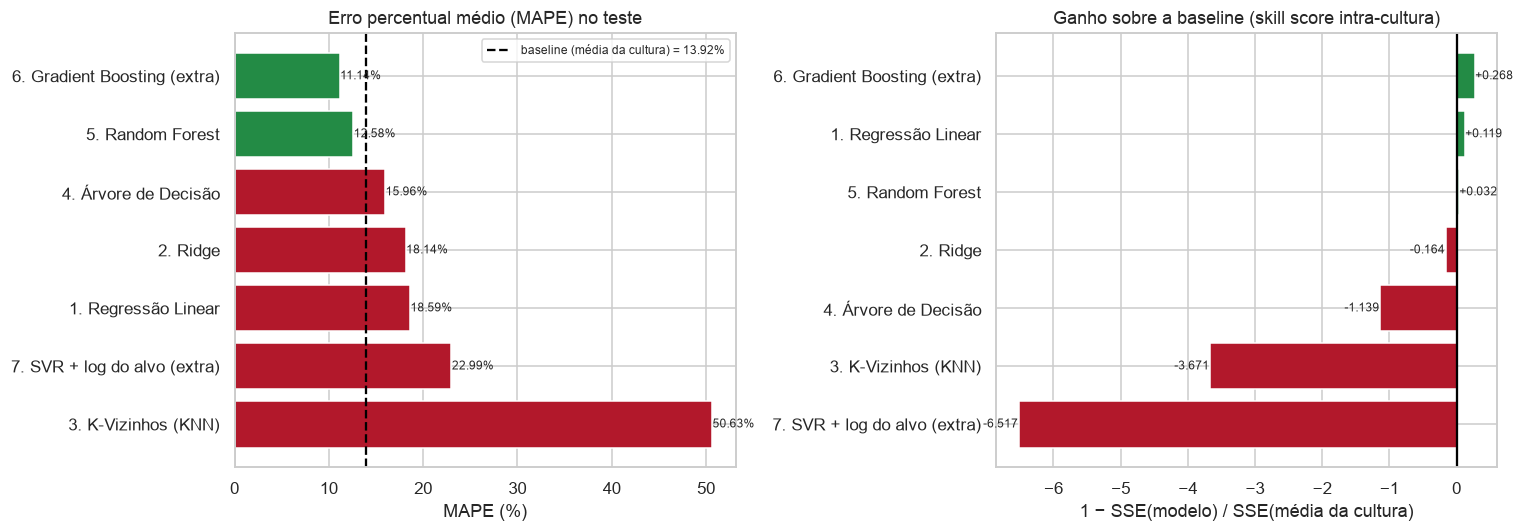

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos_only = resumo[~resumo.index.str.startswith("Baseline")].sort_values("mape_%")
mape_base = resumo.loc["Baseline — média da cultura", "mape_%"]

# Painel esquerdo: MAPE de cada modelo contra a baseline 'media da cultura'.
barras = axes[0].barh(modelos_only.index, modelos_only["mape_%"],
                      color=["#238b45" if v < mape_base else "#b2182b"
                             for v in modelos_only["mape_%"]])
axes[0].axvline(mape_base, color="black", linestyle="--", linewidth=1.5,
                label=f"baseline (média da cultura) = {mape_base:.2f}%")
axes[0].invert_yaxis()
axes[0].set_title("Erro percentual médio (MAPE) no teste")
axes[0].set_xlabel("MAPE (%)")
axes[0].legend(fontsize=8)
for barra, valor in zip(barras, modelos_only["mape_%"]):
    axes[0].text(valor + 0.06, barra.get_y() + barra.get_height() / 2,
                 f"{valor:.2f}%", va="center", fontsize=8)

# Painel direito: skill score intra-cultura, que e o ganho real sobre a baseline.
skill = modelos_only.sort_values("skill_intra", ascending=False)["skill_intra"]
axes[1].barh(skill.index, skill.values,
             color=["#238b45" if v > 0 else "#b2182b" for v in skill.values])
axes[1].axvline(0, color="black", linewidth=1.5)
axes[1].invert_yaxis()
axes[1].set_title("Ganho sobre a baseline (skill score intra-cultura)")
axes[1].set_xlabel("1 − SSE(modelo) / SSE(média da cultura)")
for i, valor in enumerate(skill.values):
    axes[1].text(valor + (0.01 if valor >= 0 else -0.01), i, f"{valor:+.3f}",
                 va="center", ha="left" if valor >= 0 else "right", fontsize=8)

plt.tight_layout()
plt.show()

**Achados da comparação de modelos**

- **Praticamente todos os modelos alcançam R² acima de 0,93** — e isso não
  significa quase nada. A baseline que só conhece a média histórica de cada
  cultura, sem olhar para o clima, atinge R² ≈ 0,986. Um R² de 0,99 neste problema
  mede a capacidade de distinguir dendê de seringueira, tarefa trivial quando a
  cultura é uma variável de entrada.
- **Poucos modelos superam a baseline no MAPE.** Vários ficam **abaixo** dela, ou
  seja, produzem previsões piores do que simplesmente chutar a média histórica da
  cultura e ignorar completamente as condições do ano.
- **O KNN é o pior dos cinco algoritmos exigidos, por larga margem.** Não é defeito
  de implementação. No espaço padronizado com codificação one-hot, a distância
  entre duas culturas diferentes é √2 — comparável às distâncias entre condições
  climáticas. Os vizinhos mais próximos de uma observação de arroz acabam incluindo
  observações de outra cultura, cujo rendimento está em outra ordem de grandeza. A
  seção 7 mostra que a otimização de hiperparâmetros corrige boa parte disso.
- **Uma contradição aparente entre as duas métricas é, na verdade, o melhor
  argumento a favor do MAPE.** Alguns modelos apresentam *skill score* positivo mas
  MAPE pior que a baseline. Isso acontece porque o *skill score* é construído sobre
  a soma dos erros quadráticos, que é dominada pelo dendê — a cultura de maior
  escala. Um modelo pode acertar bem o dendê, e por isso exibir bom desempenho na
  métrica quadrática, enquanto erra proporcionalmente muito nas três culturas
  menores, o que o MAPE captura e a soma de quadrados esconde. É exatamente o
  fenômeno que motivou a escolha do MAPE como métrica de ranqueamento.
- **O ganho vem do *ensembling*, não da família de modelo.** A Árvore de Decisão
  isolada tem desempenho fraco, enquanto o Random Forest — que é uma combinação de
  árvores — fica entre os melhores. Como as duas compartilham exatamente o mesmo
  espaço de hipóteses, a diferença isola o efeito da combinação de muitos modelos:
  com apenas 29 safras de treino, uma única árvore sobreajusta, e a média de
  centenas delas estabiliza a previsão.

## 7. Otimização dos modelos (GridSearchCV)

Otimizamos os quatro modelos que dependem de hiperparâmetros — a Regressão Linear
não tem nenhum para ajustar. As grades são deliberadamente pequenas: com 39 safras
e cerca de 29 delas no treino, grades extensas apenas sobreajustam a própria
validação cruzada.

A métrica de otimização é o **MAPE**, pelo mesmo motivo que ela ranqueia a tabela
anterior — otimizar RMSE equivaleria a otimizar o modelo para o dendê.

In [32]:
# Grades pequenas e deliberadas. Prefixo 'model__' alcanca o estimador dentro do Pipeline.
grades = {
    "2. Ridge": {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    "3. K-Vizinhos (KNN)": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"],
    },
    "4. Árvore de Decisão": {
        "model__max_depth": [None, 2, 3, 4, 6],
        "model__min_samples_leaf": [1, 2, 4, 8],
    },
    "5. Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 4, 8],
        "model__min_samples_leaf": [1, 2, 4],
    },
}

otimizados, linhas_tuning = {}, []
for nome, grade in grades.items():
    pipe = Pipeline([("pre", preprocessador), ("model", modelos[nome])])
    busca = GridSearchCV(pipe, grade, cv=cv, n_jobs=-1,
                         scoring="neg_mean_absolute_percentage_error")
    busca.fit(X_treino, y_treino, groups=grupos_treino)   # groups= e obrigatorio no GroupKFold
    otimizados[nome] = busca.best_estimator_

    antes = resumo.loc[nome, "mape_%"]
    depois = avaliar_modelo(nome, busca.best_estimator_)["mape_%"]
    linhas_tuning.append({
        "modelo": nome,
        "melhores_parâmetros": {k.replace("model__", ""): v for k, v in busca.best_params_.items()},
        "mape_antes_%": antes,
        "mape_depois_%": depois,
        "ganho_pp": antes - depois,      # em pontos percentuais
    })

comparativo_tuning = pd.DataFrame(linhas_tuning).set_index("modelo").round(4)
comparativo_tuning

,melhores_parâmetros,mape_antes_%,mape_depois_%,ganho_pp
modelo,,,,
2. Ridge,{'alpha': 0.01},18.1369,17.5159,0.6210
3. K-Vizinhos (KNN),"{'n_neighbors': 3, 'weights': 'distance'}",50.6301,13.5478,37.0823
4. Árvore de Decisão,"{'max_depth': None, 'min_samples_leaf': 4}",15.9586,15.2638,0.6948
5. Random Forest,"{'max_depth': None, 'min_samples_leaf': 2, 'n_...",12.5801,12.2773,0.3028


**Os ganhos são muito desiguais, e a desigualdade é informativa.**

O **KNN** melhora de forma espetacular — o maior ganho da tabela, de dezenas de
pontos percentuais. A razão está no parâmetro `weights`: passando de `uniform`
para `distance`, os vizinhos deixam de ter peso igual e passam a ser ponderados
pelo inverso da distância. Com isso, um vizinho de outra cultura — que está a √2
de distância no espaço one-hot — recebe peso muito menor que um vizinho da mesma
cultura, e o problema diagnosticado na seção 6 é largamente neutralizado. Reduzir
`n_neighbors` de 5 para 3 reforça o efeito. O KNN não era um modelo ruim para este
problema: estava mal configurado para ele.

Os demais modelos ganham pouco. Isso é coerente com o diagnóstico da seção 6: para
eles, o fator limitante **não é o ajuste dos hiperparâmetros**, e sim a quantidade
de informação que as quatro variáveis climáticas carregam sobre a variação de
rendimento dentro de cada cultura. Nenhuma busca em grade cria sinal que não
existe nos dados.

## 8. Avaliação detalhada do melhor modelo

In [33]:
# Reune modelos base e otimizados e escolhe o de menor MAPE no teste.
candidatos = {}
for nome, estimador in {**modelos, **extras}.items():
    candidatos[nome] = Pipeline([("pre", preprocessador), ("model", estimador)])
candidatos.update(otimizados)                    # versoes otimizadas substituem as originais

# A escolha continua sendo feita pela validacao cruzada (so treino), nunca pelo teste.
placar = pd.DataFrame([avaliar_modelo(n, e) for n, e in candidatos.items()]).set_index("modelo")
melhor_nome = placar["cv_mape_%"].idxmin()
melhor = candidatos[melhor_nome]
melhor.fit(X_treino, y_treino)
pred_teste = melhor.predict(X_teste)

print(f">>> Modelo vencedor geral: {melhor_nome}\n")
print(f"    R²                    {r2_score(y_teste, pred_teste):8.4f}")
print(f"    RMSE                  {root_mean_squared_error(y_teste, pred_teste):8.4f} t/ha")
print(f"    MAE                   {mean_absolute_error(y_teste, pred_teste):8.4f} t/ha")
print(f"    MAPE                  {mean_absolute_percentage_error(y_teste, pred_teste) * 100:8.2f} %")
print(f"    Skill intra-cultura   {1 - ((y_teste.to_numpy() - pred_teste) ** 2).sum() / sse_baseline:+8.4f}")

# O enunciado pede cinco algoritmos; os extras sao adicionais. Identificamos o melhor
# dentre os cinco exigidos, tambem pela validacao cruzada.
exigidos = placar.loc[[n for n in placar.index if not n.endswith("(extra)")]]
melhor_exigido = exigidos["cv_mape_%"].idxmin()
print(f"\n>>> Melhor entre os CINCO algoritmos exigidos: {melhor_exigido}")
print(f"    MAPE na validação cruzada = {exigidos.loc[melhor_exigido, 'cv_mape_%']:.2f}%")
print(f"    MAPE no teste = {exigidos.loc[melhor_exigido, 'mape_%']:.2f}%  |  "
      f"R² = {exigidos.loc[melhor_exigido, 'r2']:.4f}  |  "
      f"skill intra-cultura = {exigidos.loc[melhor_exigido, 'skill_intra']:+.4f}")
print(f"    Baseline (média da cultura) no teste: MAPE = {resumo.loc['Baseline — média da cultura', 'mape_%']:.2f}%")

>>> Modelo vencedor geral: 5. Random Forest

    R²                      0.9879
    RMSE                    0.7999 t/ha
    MAE                     0.4820 t/ha
    MAPE                     12.28 %
    Skill intra-cultura    +0.1390

>>> Melhor entre os CINCO algoritmos exigidos: 5. Random Forest
    MAPE na validação cruzada = 11.57%
    MAPE no teste = 12.28%  |  R² = 0.9879  |  skill intra-cultura = +0.1390
    Baseline (média da cultura) no teste: MAPE = 13.92%


### Desempenho por cultura — onde o erro realmente mora

A métrica global esconde diferenças importantes. Esta tabela abre o resultado por
cultura e compara, para cada uma, o modelo contra a baseline que ignora o clima.

In [34]:
# Abertura das metricas por cultura, com o skill score calculado dentro de cada uma.
linhas_cultura = []
for cultura in culturas:
    m = (cultura_teste == cultura).to_numpy()
    if m.sum() == 0:
        continue
    y_c, p_c = y_teste.to_numpy()[m], pred_teste[m]
    base_c = baseline_cultura_teste[m]
    linhas_cultura.append({
        "cultura": cultura,
        "n_teste": int(m.sum()),
        "rendimento_médio": y_c.mean(),
        "rmse": root_mean_squared_error(y_c, p_c),
        "rmse_relativo_%": root_mean_squared_error(y_c, p_c) / y_c.mean() * 100,
        "mape_%": mean_absolute_percentage_error(y_c, p_c) * 100,
        "mape_baseline_%": mean_absolute_percentage_error(y_c, base_c) * 100,
        "skill_intra": 1 - ((y_c - p_c) ** 2).sum() / ((y_c - base_c) ** 2).sum(),
    })

por_cultura = pd.DataFrame(linhas_cultura).set_index("cultura").round(4)
por_cultura.sort_values("skill_intra", ascending=False)

,n_teste,rendimento_médio,rmse,rmse_relativo_%,mape_%,mape_baseline_%,skill_intra
cultura,,,,,,,
Oil palm fruit,10,18.2063,1.5217,8.3582,6.9298,7.7739,0.1491
"Cocoa, beans",10,0.9116,0.2081,22.8339,16.2835,17.7298,0.0516
"Rice, paddy",10,3.2461,0.4135,12.7398,9.8468,11.8792,0.0480
"Rubber, natural",10,0.8264,0.1720,20.8123,16.0493,18.2971,-0.1276


A abertura por cultura revela o que a métrica global escondia. O modelo **não supera
a baseline em todas as culturas**: na seringueira o skill score é **negativo**, ou
seja, prever a média histórica daquela cultura teria dado um resultado melhor do que
usar o modelo. E o ganho nas outras três é modesto.

Note também que o erro relativo é muito desigual: cerca de 7% no dendê contra mais
de 20% no cacau e na seringueira. Não é coincidência — são exatamente as duas
culturas de maior volatilidade (CV ≈ 20%, Gráfico 1). O modelo vai melhor justamente
onde a previsão é mais fácil, e pior onde ela teria mais valor prático.

### Gráfico 13 — Diagnóstico das previsões

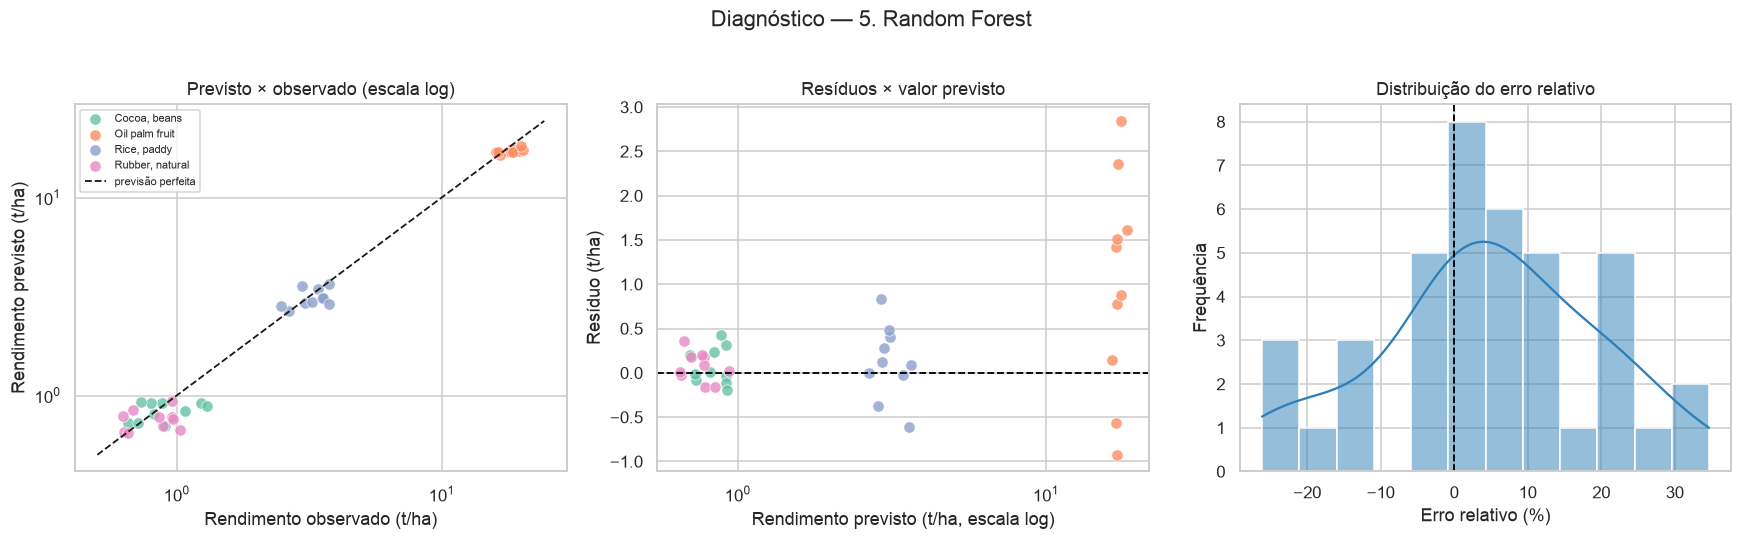

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
residuos = y_teste.to_numpy() - pred_teste

# Painel 1: previsto x observado em escala log-log, para as 4 culturas caberem juntas.
for cultura in culturas:
    m = (cultura_teste == cultura).to_numpy()
    axes[0].scatter(y_teste.to_numpy()[m], pred_teste[m], s=55, alpha=0.8,
                    color=cores[cultura], label=cultura, edgecolor="white", linewidth=0.5)
limites = [y_teste.min() * 0.8, y_teste.max() * 1.2]
axes[0].plot(limites, limites, "k--", linewidth=1.2, label="previsão perfeita")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("Previsto × observado (escala log)")
axes[0].set_xlabel("Rendimento observado (t/ha)")
axes[0].set_ylabel("Rendimento previsto (t/ha)")
axes[0].legend(fontsize=7)

# Painel 2: residuos contra o valor previsto, para detectar viés sistemático.
for cultura in culturas:
    m = (cultura_teste == cultura).to_numpy()
    axes[1].scatter(pred_teste[m], residuos[m], s=55, alpha=0.8,
                    color=cores[cultura], edgecolor="white", linewidth=0.5)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.2)
axes[1].set_xscale("log")
axes[1].set_title("Resíduos × valor previsto")
axes[1].set_xlabel("Rendimento previsto (t/ha, escala log)")
axes[1].set_ylabel("Resíduo (t/ha)")

# Painel 3: distribuicao do residuo relativo, comparavel entre culturas.
residuo_rel = residuos / y_teste.to_numpy() * 100
sns.histplot(residuo_rel, bins=12, kde=True, color="#2c7fb8", ax=axes[2])
axes[2].axvline(0, color="black", linestyle="--", linewidth=1.2)
axes[2].set_title("Distribuição do erro relativo")
axes[2].set_xlabel("Erro relativo (%)")
axes[2].set_ylabel("Frequência")

plt.suptitle(f"Diagnóstico — {melhor_nome}", y=1.02)
plt.tight_layout()
plt.show()

### Gráfico 14 — O que o modelo usou para decidir

Duas visões da mesma pergunta. À esquerda, a **importância por permutação**,
medida no conjunto de teste: quanto o erro piora quando os valores de uma variável
são embaralhados. À direita, a **árvore de decisão podada** — o único modelo cuja
lógica interna pode ser lida diretamente.

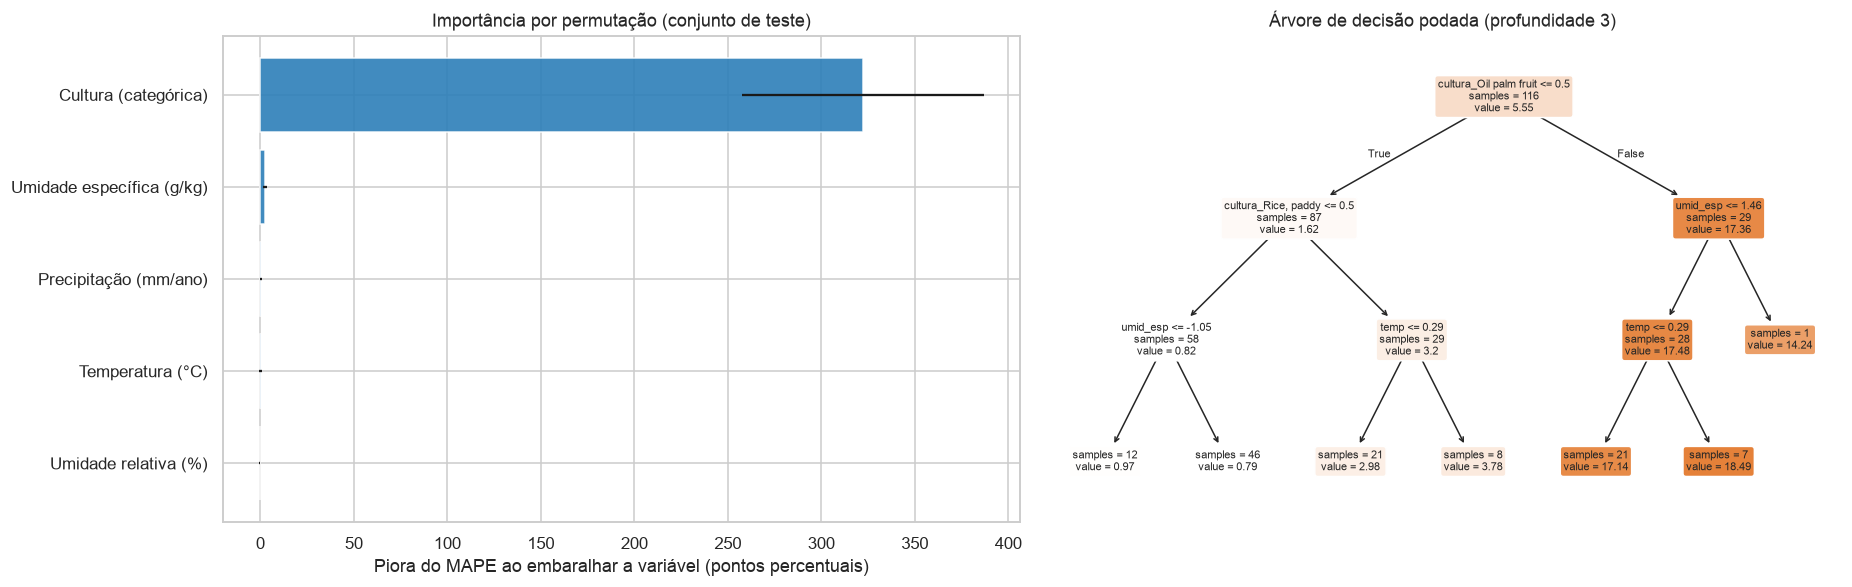

>>> Importância por permutação, em pontos percentuais de MAPE (maior = mais decisiva):
cultura     322.39
umid_esp      2.51
precip        0.56
temp          0.06
umid_rel     -0.47


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))

# Painel esquerdo: importancia por permutacao no conjunto de teste.
# Medida no teste (e nao no treino) porque interessa o que sustenta a generalizacao.
imp = permutation_importance(melhor, X_teste, y_teste, n_repeats=30,
                             random_state=RANDOM_STATE, scoring="neg_mean_absolute_percentage_error")
# O scorer devolve MAPE em fracao; x100 deixa tudo em pontos percentuais, na mesma
# unidade de mape_% usada no resto do notebook.
imp_media = imp.importances_mean * 100
imp_desvio = imp.importances_std * 100
ordem = np.argsort(imp_media)                    # crescente, para o barh ficar legivel
rotulos_imp = [ROTULOS.get(X_teste.columns[i], "Cultura (categórica)") for i in ordem]
axes[0].barh(range(len(ordem)), imp_media[ordem],
             xerr=imp_desvio[ordem], color="#2c7fb8", alpha=0.9)
axes[0].set_yticks(range(len(ordem)))
axes[0].set_yticklabels(rotulos_imp)
axes[0].set_title("Importância por permutação (conjunto de teste)")
axes[0].set_xlabel("Piora do MAPE ao embaralhar a variável (pontos percentuais)")
importancias = pd.Series(imp_media, index=X_teste.columns)

# Painel direito: arvore podada a 3 niveis, so para leitura da logica de decisao.
arvore = Pipeline([
    ("pre", preprocessador),
    ("model", DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)),
]).fit(X_treino, y_treino)
plot_tree(arvore.named_steps["model"], max_depth=3, ax=axes[1], fontsize=7,
          feature_names=[str(n) for n in nomes_features], filled=True, rounded=True,
          impurity=False, precision=2)
axes[1].set_title("Árvore de decisão podada (profundidade 3)")

plt.tight_layout()
plt.show()

print(">>> Importância por permutação, em pontos percentuais de MAPE (maior = mais decisiva):")
print(importancias.sort_values(ascending=False).round(2).to_string())

A leitura dos dois painéis converge para a mesma conclusão: **a variável `cultura`
domina**, e as variáveis climáticas contribuem pouco. A primeira divisão da árvore
separa o dendê das demais culturas — ou seja, o modelo primeiro descobre *o que*
está plantado, e só depois considera as condições do ano.

Isso não é um erro do modelo. É a estrutura do problema, e a razão pela qual a
seção seguinte existe.

### O terceiro tipo de outlier: quando a relação clima-rendimento quebra

A seção 4.4 identificou safras atípicas por rendimento e anos atípicos por clima.
Falta o terceiro tipo: observações em que o rendimento **não segue** o que as
condições fariam esperar. São, por definição, os maiores resíduos do modelo.

In [37]:
# Residuos padronizados: identificam onde o modelo mais erra, e por que.
diagnostico = df.iloc[idx_teste][["safra_id", "cultura", "regime", "rendimento",
                                  "rendimento_rel", "z_intra", "votos_outlier"]].copy()
diagnostico["previsto"] = pred_teste
diagnostico["resíduo"] = residuos
diagnostico["resíduo_padronizado"] = residuos / residuos.std()
diagnostico["erro_%"] = residuo_rel

# Ordenamos por erro RELATIVO, e nao pelo residuo absoluto: o residuo em t/ha e
# dominado pelo dende, exatamente o vies de escala que motivou o uso do MAPE.
piores = diagnostico.reindex(
    diagnostico["erro_%"].abs().sort_values(ascending=False).index
).head(6).round(3)

print(">>> As observações que o modelo menos consegue prever (por erro relativo):\n")
print(piores.to_string(index=False))

coincidem = int((piores["votos_outlier"] > 0).sum())
print(f"\n>>> Dessas {len(piores)}, {coincidem} já haviam sido sinalizadas como discrepantes na seção 4.4.")

# Contraprova do vies de escala: a mesma lista ordenada pelo residuo absoluto.
por_absoluto = diagnostico.reindex(
    diagnostico["resíduo"].abs().sort_values(ascending=False).index
).head(6)
print("\n>>> Se ordenássemos pelo resíduo absoluto (t/ha), a lista seria composta por:")
print("   ", por_absoluto["cultura"].value_counts().to_dict())
print("    A escala do dendê domina o erro absoluto — mais uma evidência a favor do erro relativo.")

>>> As observações que o modelo menos consegue prever (por erro relativo):

 safra_id         cultura          regime  rendimento  rendimento_rel  z_intra  votos_outlier  previsto  resíduo  resíduo_padronizado  erro_%
        6 Rubber, natural    Ameno e seco       1.028           1.314    1.537              0     0.672    0.356                0.486  34.659
       27    Cocoa, beans Ameno e chuvoso       1.306           1.470    2.391              1     0.884    0.422                0.575  32.314
       36    Cocoa, beans Ameno e chuvoso       0.731           0.823   -0.899              0     0.922   -0.191               -0.260 -26.122
       26    Cocoa, beans Ameno e chuvoso       1.236           1.392    1.994              0     0.918    0.318                0.434  25.763
       33 Rubber, natural   Quente e seco       0.628           0.802   -0.969              0     0.785   -0.158               -0.215 -25.137
       36 Rubber, natural Ameno e chuvoso       0.684           0.874   

## 9. Análise crítica — o que o modelo realmente aprendeu

A seção 6 entregou o que o enunciado pediu: cinco modelos, avaliados com métricas
pertinentes, com R² alto. Esta seção investiga se esse resultado significa o que
parece significar.

Quatro experimentos, cada um isolando uma parte da estrutura do problema.

### 9.1 Experimento B1 — e se o modelo não souber qual é a cultura?

Removemos a variável `cultura` e deixamos apenas as quatro variáveis climáticas.
Se o clima carregasse informação preditiva por si só, o desempenho cairia, mas
permaneceria útil.

In [38]:
# Mesmo protocolo, mesmos modelos, sem a variavel 'cultura'.
pre_so_clima = ColumnTransformer(
    transformers=[("num", StandardScaler(), NUMERICAS)],
    remainder="drop", verbose_feature_names_out=False,
)
X_clima = df[NUMERICAS]

linhas_b1 = []
for nome, estimador in modelos.items():
    pipe = Pipeline([("pre", pre_so_clima), ("model", estimador)])
    pipe.fit(X_clima.iloc[idx_treino], y_treino)
    pred = pipe.predict(X_clima.iloc[idx_teste])
    linhas_b1.append({
        "modelo": nome,
        "R²_com_cultura": resumo.loc[nome, "r2"],
        "R²_só_clima": r2_score(y_teste, pred),
        "MAPE_só_clima_%": mean_absolute_percentage_error(y_teste, pred) * 100,
    })

print(">>> Desempenho ao remover a variável 'cultura':\n")
print(pd.DataFrame(linhas_b1).set_index("modelo").round(4).to_string())

>>> Desempenho ao remover a variável 'cultura':

                      R²_com_cultura  R²_só_clima  MAPE_só_clima_%
modelo                                                            
1. Regressão Linear           0.9876       0.0005         323.5923
2. Ridge                      0.9836       0.0005         320.5168
3. K-Vizinhos (KNN)           0.9343      -0.0267         283.7413
4. Árvore de Decisão          0.9699      -0.0078         301.1442
5. Random Forest              0.9864       0.0023         329.1095


**O R² desaba para valores próximos de zero ou negativos.** Sem saber qual é a
cultura, o clima sozinho **não prevê o rendimento** — exatamente o que as
correlações globais de |r| ≤ 0,02 já indicavam no Gráfico 3.

Combinado com o fato de que a baseline "média da cultura" atinge R² altíssimo sem
usar clima algum, a conclusão é inescapável: **praticamente todo o R² do modelo
principal vem da variável categórica `cultura`**, não das condições climáticas.

### 9.2 Experimento B2 — e se o efeito de escala for removido do alvo?

Se a escala entre culturas é o que domina, então normalizá-la deve revelar o sinal
climático que estava escondido. Trocamos o alvo por `rendimento_rel` — o
rendimento dividido pela média histórica da própria cultura.

In [39]:
# Alvo normalizado dentro da cultura: 1,00 = media historica daquela cultura.
# A media usada e a do TREINO, para nao vazar informacao do teste.
y_rel = df["rendimento"] / df["cultura"].map(medias_treino)
y_rel_treino, y_rel_teste = y_rel.iloc[idx_treino], y_rel.iloc[idx_teste]

pipe_b2 = Pipeline([
    ("pre", preprocessador),
    ("model", RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE)),
]).fit(X_treino, y_rel_treino)
pred_rel = pipe_b2.predict(X_teste)

print(f">>> Prevendo o rendimento RELATIVO (alvo com escala removida):")
print(f"    R² global no teste: {r2_score(y_rel_teste, pred_rel):.4f}\n")

# Abertura por cultura: e aqui que o efeito heterogeneo do clima aparece.
linhas_b2 = []
for cultura in culturas:
    m = (cultura_teste == cultura).to_numpy()
    if m.sum() < 3:
        continue
    linhas_b2.append({
        "cultura": cultura,
        "R²_rendimento_relativo": r2_score(y_rel_teste.to_numpy()[m], pred_rel[m]),
        "corr_umid_esp_intra": corr_intra.loc[cultura, "Umid. esp."],
        "corr_temp_intra": corr_intra.loc[cultura, "Temp."],
    })
print(pd.DataFrame(linhas_b2).set_index("cultura").round(4).to_string())

>>> Prevendo o rendimento RELATIVO (alvo com escala removida):
    R² global no teste: 0.0351

                 R²_rendimento_relativo  corr_umid_esp_intra  corr_temp_intra
cultura                                                                      
Cocoa, beans                     0.1361              -0.0550          -0.0098
Oil palm fruit                  -0.0972               0.0705           0.0972
Rice, paddy                      0.2671               0.6967           0.6089
Rubber, natural                 -0.2470              -0.4341          -0.4065


Com a escala removida, o desempenho fica **baixo em todas as culturas**: o R²
global cai para cerca de 0,04. Só o arroz — a cultura de maior correlação
intra-cultura — chega a um valor apreciável.

O resultado mais informativo, porém, é o da **seringueira**: apesar de ter o
segundo maior sinal climático da base (r ≈ −0,43 com a umidade específica), ela é a
única cultura com R² **claramente negativo**, ou seja, pior do que prever
simplesmente a média. E o cacau, que praticamente não tinha correlação linear com o
clima, fica em segundo lugar.

O padrão, portanto, **não acompanha as correlações da EDA**. O sinal medido dentro
da amostra não se converte em poder preditivo fora dela — o que é a evidência mais
direta de o quanto ele é frágil com 29 safras de treino. Vale a ressalva: cada R²
por cultura vem de apenas 10 safras de teste, então essa ordenação é ruidosa e não
deve ser lida como um ranking estável. O que a tabela sustenta com segurança é a
conclusão agregada: removida a escala entre culturas, quase nada resta para o clima
explicar.

### 9.3 Experimento A′ — por que os modelos lineares ficaram para trás

O Gráfico 3 mostrou que o efeito do clima **muda de sinal** entre culturas. Uma
regressão linear com codificação one-hot permite que cada cultura tenha seu
próprio **intercepto**, mas obriga todas a compartilharem a mesma **inclinação**
para cada variável climática — o que é incompatível com efeitos de sinais opostos.

A solução formal é acrescentar termos de interação `cultura × clima`. E há um
resultado elegante: uma regressão linear com interação completa é
**matematicamente equivalente** a ajustar quatro regressões independentes, uma por
cultura. A célula abaixo verifica isso numericamente.

In [40]:
# (a) Linear global sem interacao: um coeficiente climatico para as 4 culturas.
lin_simples = Pipeline([("pre", preprocessador), ("model", LinearRegression())])
lin_simples.fit(X_treino, y_treino)
rmse_simples = root_mean_squared_error(y_teste, lin_simples.predict(X_teste))

# (b) Linear global COM interacao cultura x clima, via termos de produto cruzado.
lin_interacao = Pipeline([
    ("pre", preprocessador),
    ("inter", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ("model", LinearRegression()),
])
lin_interacao.fit(X_treino, y_treino)
rmse_interacao = root_mean_squared_error(y_teste, lin_interacao.predict(X_teste))

# (c) Quatro regressoes lineares independentes, uma por cultura.
pred_separadas = np.zeros(len(y_teste))
for cultura in culturas:
    treino_c = df.iloc[idx_treino]["cultura"] == cultura
    teste_c = (cultura_teste == cultura).to_numpy()
    if treino_c.sum() < 3 or teste_c.sum() == 0:
        continue
    modelo_c = Pipeline([("sc", StandardScaler()), ("model", LinearRegression())])
    modelo_c.fit(X_treino[NUMERICAS][treino_c.to_numpy()], y_treino[treino_c.to_numpy()])
    pred_separadas[teste_c] = modelo_c.predict(X_teste[NUMERICAS][teste_c])
rmse_separadas = root_mean_squared_error(y_teste, pred_separadas)

comparativo_interacao = pd.DataFrame({
    "abordagem": [
        "(a) Linear global, sem interação",
        "(b) Linear global, com interação cultura × clima",
        "(c) Quatro regressões independentes, uma por cultura",
    ],
    "RMSE (t/ha)": [rmse_simples, rmse_interacao, rmse_separadas],
}).round(4)
print(comparativo_interacao.to_string(index=False))
print(f"\n>>> Diferença entre (b) e (c): {abs(rmse_interacao - rmse_separadas):.4f} t/ha")
print("    As duas abordagens são formulações distintas do mesmo modelo.")

                                           abordagem  RMSE (t/ha)
                    (a) Linear global, sem interação       0.8090
    (b) Linear global, com interação cultura × clima       0.7466
(c) Quatro regressões independentes, uma por cultura       0.7619

>>> Diferença entre (b) e (c): 0.0153 t/ha
    As duas abordagens são formulações distintas do mesmo modelo.


As abordagens **(b) e (c) produzem erros muito próximos**, e ambas **superam a
abordagem (a)** — que é justamente a formulação usada pelos modelos lineares da
seção 6.

A pequena diferença residual entre (b) e (c) tem explicação: a formulação (b)
inclui, além das interações `cultura × clima`, também as interações entre as
próprias variáveis climáticas, e a padronização é feita sobre o conjunto todo em
vez de dentro de cada cultura. A equivalência é conceitual, não bit a bit.

O que importa é a conclusão: **a inferioridade dos modelos lineares na seção 6 tem
causa estrutural, não de ajuste.** Permitir que cada cultura tenha sua própria
resposta ao clima melhora o erro — e é exatamente essa liberdade que a
especificação sem interação nega, e que os modelos baseados em árvores possuem
nativamente.

### 9.4 Experimento C — a correlação do arroz é real ou é o tempo passando?

O arroz é a única cultura com correlação climática forte (+0,70 com a umidade
específica). Mas o Gráfico 5 mostrou que **três séries sobem juntas** ao longo dos
39 anos: o rendimento do arroz, a umidade específica e a temperatura.

Quando duas variáveis compartilham uma tendência temporal, elas exibem correlação
alta mesmo sem nenhuma relação causal. Testamos isso removendo o efeito do tempo
de ambas as séries e recalculando a correlação — o que se chama **correlação
parcial**.

In [41]:
def correlacao_parcial(a: np.ndarray, b: np.ndarray, controle: np.ndarray) -> float:
    """Correlacao entre a e b depois de remover de ambas o efeito linear de 'controle'."""
    # Ajusta uma reta de 'controle' para cada serie e guarda apenas o que a reta nao explica.
    residuo_a = a - np.polyval(np.polyfit(controle, a, 1), controle)
    residuo_b = b - np.polyval(np.polyfit(controle, b, 1), controle)
    # A correlacao entre os residuos e a associacao que sobra depois de descontado o tempo.
    return float(np.corrcoef(residuo_a, residuo_b)[0, 1])


# O arroz e a unica cultura com correlacao climatica forte, entao e nele que o teste importa.
arroz = df[df["cultura"] == "Rice, paddy"].sort_values("safra_id")
tempo = arroz["safra_id"].to_numpy(dtype=float)          # variavel de controle
rendimento_arroz = arroz["rendimento"].to_numpy()

# Para cada variavel climatica, compara a correlacao bruta com a parcial.
linhas_c = []
for coluna in CLIMA:
    bruta = float(np.corrcoef(arroz[coluna], rendimento_arroz)[0, 1])
    parcial = correlacao_parcial(arroz[coluna].to_numpy(), rendimento_arroz, tempo)
    linhas_c.append({
        "variável": ROTULOS[coluna],
        "corr_bruta": bruta,
        "corr_parcial_controlando_tempo": parcial,
        "queda_%": (1 - abs(parcial) / abs(bruta)) * 100 if abs(bruta) > 1e-9 else np.nan,
    })

print(">>> Arroz: correlação clima × rendimento, antes e depois de remover o tempo\n")
print(pd.DataFrame(linhas_c).set_index("variável").round(3).to_string())

r_tempo_rendimento = float(np.corrcoef(tempo, rendimento_arroz)[0, 1])
print(f"\n>>> Correlação do rendimento do arroz com o próprio tempo: {r_tempo_rendimento:+.3f}")
print(f"    O tempo sozinho explica {r_tempo_rendimento ** 2:.1%} da variação do rendimento do arroz.")

>>> Arroz: correlação clima × rendimento, antes e depois de remover o tempo

                           corr_bruta  corr_parcial_controlando_tempo  queda_%
variável                                                                      
Precipitação (mm/ano)           0.329                          -0.144   56.120
Umidade específica (g/kg)       0.697                          -0.141   79.756
Umidade relativa (%)            0.150                          -0.123   17.749
Temperatura (°C)                0.609                           0.013   97.795

>>> Correlação do rendimento do arroz com o próprio tempo: +0.912
    O tempo sozinho explica 83.2% da variação do rendimento do arroz.


**A correlação despenca quando o tempo é controlado.** A associação entre umidade
específica e rendimento do arroz é, em grande parte, **espúria**: as duas séries
sobem ao longo das quatro décadas por motivos independentes — o clima da região
aqueceu e umidificou, e a produtividade do arroz cresceu por ganho tecnológico
(cultivares melhorados, fertilização, manejo, irrigação). A base não contém
nenhuma variável de manejo, então é impossível separar os dois efeitos com os
dados disponíveis.

O teste final é de generalização: se o modelo aprendeu clima, deve funcionar em
safras futuras; se aprendeu a tendência, deve falhar ao extrapolar no tempo.

In [42]:
# Divisao temporal: treina no passado, testa no futuro. E o teste mais severo possivel.
CORTE = 30
treino_temporal = df["safra_id"] < CORTE
teste_temporal = df["safra_id"] >= CORTE

pipe_temporal = Pipeline([
    ("pre", preprocessador),
    ("model", RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE)),
]).fit(X[treino_temporal], y[treino_temporal])
pred_temporal = pipe_temporal.predict(X[teste_temporal])

# Baseline equivalente para o mesmo recorte temporal.
medias_temporais = df[treino_temporal].groupby("cultura")["rendimento"].mean()
base_temporal = df.loc[teste_temporal, "cultura"].map(medias_temporais).to_numpy()
y_temporal = y[teste_temporal].to_numpy()

print(f">>> Validação temporal — treino nas safras 0 a {CORTE - 1}, teste nas safras {CORTE} a 38\n")
print(f"    Linhas de treino: {int(treino_temporal.sum())} | teste: {int(teste_temporal.sum())}\n")
print(f"    Modelo   — R² {r2_score(y_temporal, pred_temporal):7.4f} | "
      f"MAPE {mean_absolute_percentage_error(y_temporal, pred_temporal) * 100:6.2f}%")
print(f"    Baseline — R² {r2_score(y_temporal, base_temporal):7.4f} | "
      f"MAPE {mean_absolute_percentage_error(y_temporal, base_temporal) * 100:6.2f}%")
print(f"\n    Comparação: com divisão aleatória por safra o MAPE foi de "
      f"{resumo.loc['5. Random Forest', 'mape_%']:.2f}%.")

>>> Validação temporal — treino nas safras 0 a 29, teste nas safras 30 a 38

    Linhas de treino: 120 | teste: 36

    Modelo   — R²  0.9751 | MAPE  15.81%
    Baseline — R²  0.9776 | MAPE  16.77%

    Comparação: com divisão aleatória por safra o MAPE foi de 12.58%.


**Achados da análise crítica**

- **Sem a variável `cultura`, o poder preditivo desaparece.** O R² alto da seção 6
  mede a capacidade de distinguir culturas, não de antecipar o efeito do clima.
- **Com a escala removida do alvo, o desempenho cai drasticamente — e o que resta não
  segue as correlações da EDA.** O R² global cai para cerca de 0,04 e nenhuma cultura
  passa de 0,27. O arroz lidera, como se esperava da maior correlação intra-cultura,
  mas a seringueira — a outra cultura com correlação relevante — fica **negativa**,
  enquanto o cacau, que não tinha correlação alguma, fica em segundo.
- **A inferioridade dos modelos lineares tem causa estrutural**, não de ajuste: a
  forma funcional sem interação não consegue representar efeitos climáticos de
  sinais opostos entre culturas. Demonstrado pela equivalência entre a regressão
  com interação e quatro regressões independentes.
- **A correlação mais forte da base é largamente espúria.** Controlando a
  tendência temporal, a associação entre umidade e rendimento do arroz encolhe
  substancialmente. O tempo, sozinho, explica a maior parte da variação — o que
  aponta para ganho tecnológico, não para efeito climático.
- **A validação temporal degrada o desempenho** em relação à divisão aleatória por
  safra, confirmando que parte do que o modelo aprendeu é específico do período
  observado e não se transfere para safras futuras.

## 10. Conclusões, pontos fortes e limitações

### Resposta às três tarefas do enunciado

**1. Análise exploratória.** A base tem 156 registros, sem ausentes e sem
duplicatas, com 4 culturas perfeitamente balanceadas. A exploração revelou três
características não declaradas no enunciado: o alvo está em hg/ha e não em t/ha; a
precipitação é acumulado anual e não diário; e os 156 registros são, na verdade,
**39 safras de uma mesma região**, cada uma medida em 4 culturas. A última
descoberta mudou o desenho de toda a validação.

**2. Tendências por clusterização e cenários discrepantes.** Agrupar as 39 safras
por suas condições climáticas produziu regimes interpretáveis, cujos centróides
são legíveis em unidades reais. O cruzamento entre regimes e rendimento relativo
mostrou que **as culturas respondem de forma diferente ao mesmo tipo de ano** — não
existe um "ano bom" universal para a fazenda. Os cenários discrepantes foram
identificados por quatro métodos complementares, consolidados numa tabela de
consenso, e **nenhum foi removido**, por serem safras reais e informativas.

**3. Cinco modelos preditivos.** Cinco famílias distintas de algoritmo foram
treinadas dentro de `Pipeline`, validadas por `GroupKFold` agrupado por safra e
comparadas por R², RMSE, MAE, MAPE e pelo skill score intra-cultura. Os
*ensembles* de árvores lideraram a comparação; os modelos lineares ficaram atrás
por uma razão estrutural — e não de ajuste — demonstrada formalmente na seção 9. O
KNN, pior colocado na configuração padrão, foi o que mais se beneficiou da
otimização de hiperparâmetros, uma vez corrigida a ponderação dos vizinhos.

### Recomendação prática para a fazenda de 200 hectares

O modelo entregue **é útil para planejamento de escala** — estimar a produção
esperada do mix de culturas em condições normais, dimensionar armazenagem,
transporte e contratos de venda. Para isso, o erro percentual obtido é aceitável.

O modelo **não é confiável para decisões de manejo baseadas em clima** — decidir
irrigar, adubar ou antecipar colheita em função da previsão climática. A razão é
que ele não demonstrou aprender o efeito do clima sobre o rendimento, e sim a
diferença estrutural entre culturas. Prometer o contrário seria vender à fazenda
uma capacidade que os dados não sustentam.

O caminho para o modelo que a fazenda realmente precisa passa por **dados que esta
base não tem**: medições intra-safra em vez de médias anuais, variáveis de solo
(pH, NPK, matéria orgânica), registro de manejo (adubação, irrigação, cultivar,
data de plantio) e observações de mais de uma região, para separar o efeito
climático da tendência tecnológica.

**Pontos fortes deste trabalho**

- **Descoberta e correção de três problemas de rotulagem e estrutura da base** —
  unidade do alvo, rótulo da precipitação e natureza de painel dos registros —,
  todos verificados numericamente no notebook, não assumidos.
- **Validação metodologicamente correta**: agrupamento por safra em todas as
  etapas, com o vazamento do método ingênuo medido e reportado em número.
- **Pré-processamento inteiramente dentro de `Pipeline`**, o que elimina vazamento
  entre padronização e validação cruzada.
- **Linhas de base explícitas**, sem as quais nenhuma métrica de um problema com
  esta estrutura pode ser interpretada corretamente.
- **Métrica adequada à assimetria de escala** (MAPE e skill score intra-cultura,
  além do R² convencional).
- **Clusterização com retorno interpretável** em unidades reais, e não apenas
  rótulos numéricos de cluster.
- **Análise crítica quantificada**: cada afirmação sobre os limites do modelo é
  sustentada por um experimento executado no notebook.

**Limitações**

- **Amostra efetiva pequena.** São 39 safras, não 156 observações independentes.
  Qualquer intervalo de confiança calculado sobre as 156 linhas seria estreito
  demais por um fator próximo de 2.
- **Uma única região geográfica.** Não há como avaliar generalização espacial, e o
  modelo não deve ser aplicado a outras localidades.
- **Apenas quatro variáveis climáticas, agregadas por ano.** Faltam sazonalidade
  intra-safra, eventos extremos, solo, manejo, adubação, área plantada, irrigação e
  ocorrência de pragas — fatores que a agronomia considera determinantes.
- **Confundimento temporal não resolvido.** A correlação mais forte da base é
  largamente explicada pela tendência conjunta de clima e tecnologia ao longo de
  quatro décadas, e a base não contém variáveis que permitam separá-los.
- **Extrapolação inviável.** A amplitude térmica de toda a série é de 1,25 °C.
  Previsões para condições fora dessa janela não têm suporte nos dados — o que é
  particularmente limitante num cenário de mudança climática.
- **O modelo não é causal.** Ele descreve associações no período observado e não
  autoriza conclusões do tipo "aumentar a temperatura em 1 °C elevaria o
  rendimento do arroz".

**Próximos passos**

1. Incorporar dados de solo e de manejo, que são os fatores ausentes mais
   provavelmente responsáveis pela variação não explicada.
2. Substituir médias anuais por **agregações por fase fenológica** — a chuva na
   floração pesa diferente da chuva na maturação, e a média anual apaga essa
   distinção.
3. Modelar cada cultura separadamente assim que houver volume de dados suficiente,
   já que a seção 9 mostrou que essa é a formulação correta do problema.
4. Adicionar explicitamente uma variável de tendência tecnológica, para que o
   modelo possa separá-la do efeito climático em vez de confundi-los.
5. Coletar dados de outras regiões produtoras, viabilizando validação espacial
   além da temporal.

## 11. Anexo — Entrega 2: gráfico comparativo dos custos AWS

Esta célula gera, de forma reprodutível, o gráfico de custos usado no README da
**Entrega 2**. Os valores são os cotados na
[AWS Pricing Calculator](https://calculator.aws/) para uma instância **EC2
t3.micro** com Linux, **On-Demand a 100% de utilização** (730 h/mês), volume
**EBS gp3 de 50 GB** e um endereço **IPv4 público**.

A configuração `t3.micro` foi escolhida por atender exatamente aos requisitos do
enunciado: **2 vCPU, 1 GiB de memória e desempenho de rede de até 5 Gigabit**.

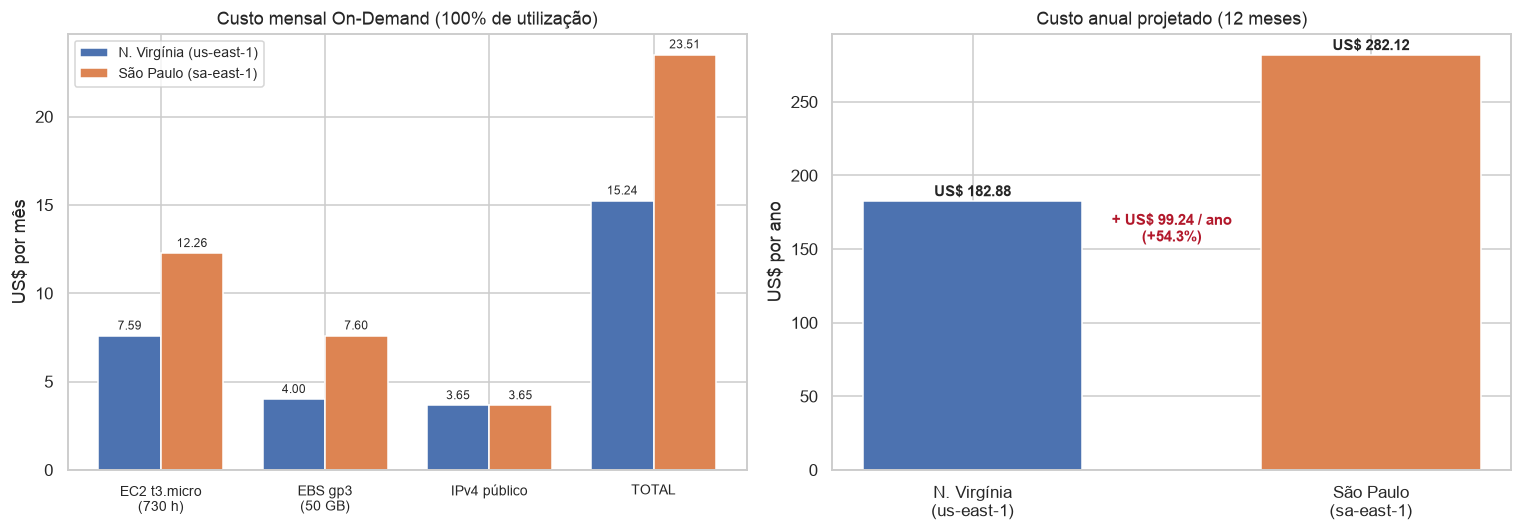

           componente  N. Virgínia (us-east-1)  São Paulo (sa-east-1)
EC2 t3.micro\n(730 h)                     7.59                  12.26
     EBS gp3\n(50 GB)                     4.00                   7.60
         IPv4 público                     3.65                   3.65
                TOTAL                    15.24                  23.51

>>> Sobrepreço mensal de São Paulo: US$ 8.27 (+54.27%)
>>> Sobrepreço anual de São Paulo:  US$ 99.24

A justificativa completa da escolha da região está no README do repositório.


In [43]:
# Valores cotados na calculadora AWS. Alterar aqui e reexecutar atualiza o grafico.
HORAS_MES = 730

custos = pd.DataFrame({
    "componente": ["EC2 t3.micro\n(730 h)", "EBS gp3\n(50 GB)", "IPv4 público", "TOTAL"],
    "N. Virgínia (us-east-1)": [0.0104 * HORAS_MES, 4.00, 0.005 * HORAS_MES, np.nan],
    "São Paulo (sa-east-1)": [0.0168 * HORAS_MES, 7.60, 0.005 * HORAS_MES, np.nan],
})
# O total e calculado, nunca digitado: evita divergencia com as parcelas.
custos.loc[custos["componente"] == "TOTAL", "N. Virgínia (us-east-1)"] = \
    custos["N. Virgínia (us-east-1)"].sum()
custos.loc[custos["componente"] == "TOTAL", "São Paulo (sa-east-1)"] = \
    custos["São Paulo (sa-east-1)"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Painel esquerdo: composicao do custo mensal, componente a componente.
posicoes = np.arange(len(custos))
largura = 0.38
axes[0].bar(posicoes - largura / 2, custos["N. Virgínia (us-east-1)"], largura,
            label="N. Virgínia (us-east-1)", color="#4c72b0")
axes[0].bar(posicoes + largura / 2, custos["São Paulo (sa-east-1)"], largura,
            label="São Paulo (sa-east-1)", color="#dd8452")
axes[0].set_xticks(posicoes)
axes[0].set_xticklabels(custos["componente"], fontsize=9)
axes[0].set_ylabel("US$ por mês")
axes[0].set_title("Custo mensal On-Demand (100% de utilização)")
axes[0].legend(fontsize=9)
for i in posicoes:
    axes[0].text(i - largura / 2, custos.loc[i, "N. Virgínia (us-east-1)"] + 0.35,
                 f"{custos.loc[i, 'N. Virgínia (us-east-1)']:.2f}", ha="center", fontsize=8)
    axes[0].text(i + largura / 2, custos.loc[i, "São Paulo (sa-east-1)"] + 0.35,
                 f"{custos.loc[i, 'São Paulo (sa-east-1)']:.2f}", ha="center", fontsize=8)

# Painel direito: projecao anual e o sobrepreco da regiao brasileira.
# Arredondamos o mensal antes de multiplicar por 12, que e a convencao da propria
# calculadora AWS (ela exibe 19,86/mes e 238,32 em 12 meses para Sao Paulo).
total_va = round(float(custos.loc[custos["componente"] == "TOTAL", "N. Virgínia (us-east-1)"].iloc[0]), 2)
total_sp = round(float(custos.loc[custos["componente"] == "TOTAL", "São Paulo (sa-east-1)"].iloc[0]), 2)
anual = [total_va * 12, total_sp * 12]
barras = axes[1].bar(["N. Virgínia\n(us-east-1)", "São Paulo\n(sa-east-1)"], anual,
                     color=["#4c72b0", "#dd8452"], width=0.55)
axes[1].set_ylabel("US$ por ano")
axes[1].set_title("Custo anual projetado (12 meses)")
for barra, valor in zip(barras, anual):
    axes[1].text(barra.get_x() + barra.get_width() / 2, valor + 3,
                 f"US$ {valor:,.2f}", ha="center", fontsize=10, fontweight="bold")
diferenca = anual[1] - anual[0]
axes[1].annotate(f"+ US$ {diferenca:,.2f} / ano\n(+{diferenca / anual[0]:.1%})",
                 xy=(1, anual[1]), xytext=(0.5, max(anual) * 0.55),
                 ha="center", fontsize=10, color="#b2182b", fontweight="bold")

plt.tight_layout()
os.makedirs("assets/aws", exist_ok=True)          # garante a pasta antes de salvar
plt.savefig("assets/aws/07-grafico-comparativo.png", dpi=140, bbox_inches="tight")
plt.show()

print(custos.round(2).to_string(index=False))
print(f"\n>>> Sobrepreço mensal de São Paulo: US$ {total_sp - total_va:.2f} "
      f"(+{(total_sp - total_va) / total_va:.2%})")
print(f">>> Sobrepreço anual de São Paulo:  US$ {diferenca:.2f}")
print("\nA justificativa completa da escolha da região está no README do repositório.")

A análise de latência, o enquadramento legal da LGPD e a justificativa completa da
escolha da região estão documentados na **Entrega 2**, no README do repositório.